# Lecture 12, Climate data analysis with xarray

> Gridded climate data: selection, climatology, anomalies, resampling and masking

In [1]:
# Google Colab setup: install the packages this notebook uses.
# Runs only on Colab; skipped in Binder or a local Jupyter install.
import sys
if "google.colab" in sys.modules:
    %pip install -q numpy matplotlib xarray netcdf4 pooch pythia-datasets nc-time-axis

# Climate data analysis with xarray

Every model we have built so far in this course produced its own numbers. A
zero-dimensional energy balance model gives you one temperature; the lumped
hydrological model gives you one hydrograph; the advection-diffusion solver of
Lecture 9 gives you a temperature profile on a grid you defined yourself.

Real climate science works the other way round. The data arrives first -- from a
satellite, a reanalysis, or a global climate model -- and it arrives as a
**multi-dimensional labelled array**: a temperature that is a function of
$(\text{time}, \text{latitude}, \text{longitude})$, sometimes with depth or
pressure level on top of that. Before you can ask a scientific question of such a
dataset you have to be fluent in a small set of operations:

* **select** a place, a time, or a box out of the grid,
* **aggregate** over the dimensions you do not care about,
* **group** by season or month to get a **climatology**,
* subtract that climatology to get an **anomaly**,
* **resample** or smooth to separate slow signals from fast noise,
* **mask** out the cells that are not part of your problem,
* and **fit a trend** -- with an honest statement of how much to believe it.

That is exactly what this notebook teaches, using
[**xarray**](https://docs.xarray.dev/) -- the library the entire Python climate
stack is built on.

```{admonition} Where this material comes from
:class: seealso
This notebook is adapted for CE524 from the **ClimateMatch Academy /
Computational Tools for Climate Science** tutorials, Week 1 Day 1,
*Climate System Overview* (Tutorials 4-9, by Sloane Garelick and Julia Kent),
which are themselves built on
[Project Pythia Foundations](https://foundations.projectpythia.org/).
Full credits are at the end of the notebook.
```

**By the end of this notebook you should be able to:**

1. Describe the anatomy of an xarray `Dataset` and `DataArray` -- dimensions,
   coordinates, variables and attributes -- and say why labelled arrays beat raw
   NumPy for climate work.
2. Select data by **label** (`.sel`) and by **position** (`.isel`), including
   nearest-neighbour lookups and slices.
3. Apply **arithmetic** to a whole array at once (vectorization) and use
   **aggregation** methods to reduce dimensions.
4. Compute a **monthly climatology** with `.groupby()` and turn it into an
   **anomaly**.
5. Explain why a global mean must be **area-weighted**, and do it two ways.
6. Use `.resample()`, `.rolling()` and `.coarsen()`, and say how they differ.
7. Use `.where()` to **mask** data on one or several conditions.
8. **Fit a trend and say how much to believe it**: least squares, Mann-Kendall
   and Theil-Sen, why autocorrelation makes the textbook p-value wrong, and how
   to map trends across a grid.

## Setup

We use one dataset throughout: monthly **sea surface temperature** (SST) from
**CESM2**, the Community Earth System Model version 2, as submitted to CMIP6.
In CMIP vocabulary the variable is called `tos`, "temperature of the surface" of
the ocean. The file covers 2000-2014 on a 1 degree x 1 degree grid, and is
fetched (and cached) for you by `pythia_datasets`.

SST is a good teaching dataset for a hydroclimatology course, and not only
because it is easy to plot. The ocean surface is where nearly all the
atmosphere's water vapour comes from, so the SST field is the *boundary
condition* of the hydrological cycle. The monsoon that dominates Indian
hydrology is driven by the land-sea thermal contrast, and its interannual swings
track SST anomalies in the Indian and Pacific Oceans. Everything you learn to do
to `tos` here transfers unchanged to precipitation, runoff, soil moisture or
evaporation fields.

In [2]:
import warnings

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pythia_datasets import DATASETS

# nc_time_axis is not called directly, but importing it teaches matplotlib how to
# put CESM2's 365-day cftime dates on an axis. Without it, every time-series plot
# below raises an ImportError.
import nc_time_axis  # noqa: F401

# the CESM2 file declares its missing-value twice, in two dtypes; xarray warns
# about it on every open. Harmless here -- both mean "land".
warnings.filterwarnings("ignore", category=xr.SerializationWarning)

%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (9, 4)

## Section 1: The anatomy of a Dataset

`xr.open_dataset` reads a netCDF file -- the standard format of climate data --
and returns a `Dataset`. Run the cell and read the repr carefully; it is the
single most useful habit in this whole notebook.

In [3]:
filepath = DATASETS.fetch("CESM2_sst_data.nc")
ds = xr.open_dataset(filepath)
ds

<xarray.Dataset> Size: 47MB
Dimensions:    (time: 180, d2: 2, lat: 180, lon: 360)
Coordinates:
  * time       (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: d2
Data variables:
    time_bnds  (time, d2) object 3kB ...
    lat_bnds   (lat, d2) float64 3kB ...
    lon_bnds   (lon, d2) float64 6kB ...
    tos        (time, lat, lon) float32 47MB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                972
    ...                     ...
    sub_experiment_id:      none
    table_id:               Omon
    tracking_id:            hdl:21.14100/2975ffd3-1d7b-47e3-961a-33f212ea4eb2
    variable_id:            tos
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r11i1p1f1

Four things to read off that repr:

* **Dimensions** -- `time: 180`, `lat: 180`, `lon: 360`. 180 months is 15 years
  of monthly data; 180 x 360 is a 1-degree global grid.
* **Coordinates** -- the actual *labels* along each dimension: real dates, real
  latitudes in degrees north, real longitudes in degrees east (0 to 360 here,
  not -180 to 180 -- always check).
* **Data variables** -- `tos` is the one we want. The `_bnds` variables record
  the edges of each grid cell and each month.
* **Attributes** -- the metadata CMIP6 requires, including which model and which
  experiment produced the file.

A single variable is a `DataArray`, reachable either as `ds.tos` or `ds["tos"]`
(the second form always works, including for names with spaces or names that
clash with a method).

In [4]:
sst = ds["tos"]
sst

<xarray.DataArray 'tos' (time: 180, lat: 180, lon: 360)> Size: 47MB
[11664000 values with dtype=float32]
Coordinates:
  * time     (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

This is the point of xarray. In plain NumPy this object would be an array of
shape `(180, 180, 360)` and you would have to *remember* that axis 0 is time and
axis 1 is latitude, and separately carry around the vectors of dates and
latitudes. Here the labels travel with the data, so you can write
`sst.mean(dim="time")` instead of `arr.mean(axis=0)` -- code that says what it
means and cannot silently average the wrong axis.

Note the `units` attribute: `degC`. Metadata like this is what lets xarray label
your plot axes automatically, and what lets you catch a unit bug before it
becomes a paper correction.

In [5]:
print("dimensions :", sst.dims)
print("shape      :", sst.shape)
print("units      :", sst.attrs["units"])
print("time type  :", type(ds.time.values[0]).__name__)

dimensions : ('time', 'lat', 'lon')
shape      : (180, 180, 360)
units      : degC
time type  : DatetimeNoLeap


```{admonition} cftime, not datetime
:class: note
The time coordinate is made of `cftime.DatetimeNoLeap` objects, not NumPy
datetimes. CESM2 runs on a **365-day calendar with no leap years**, which NumPy
cannot represent, so xarray falls back to `cftime`. Almost everything
(`.sel("2014-09")`, `.dt.month`, `.groupby`, `.resample`) works the same way --
but a few pandas-only tricks will not, and this is the usual explanation when
they fail.
```

## Section 2: Selection -- by label and by position

There are two ways to cut into a labelled array, and confusing them is the most
common beginner error.

* `.isel()` selects by **integer position**, exactly like NumPy indexing.
  `sst.isel(time=0)` is "the first month", whenever that is.
* `.sel()` selects by **coordinate label** -- an actual date, an actual
  latitude. `sst.sel(time="2014-09")` is "September 2014", whatever its
  position.

Use `.sel()` for science and `.isel()` for bookkeeping.

In [6]:
# by position: the very first month in the file
first_month = sst.isel(time=0)
print("first month :", ds.time.values[0])
print("shape       :", first_month.shape)   # a lat x lon map

# by label: one specific month
sept_2014 = sst.sel(time="2014-09")
print("selected    :", sept_2014.time.values)

first month : 2000-01-15 12:00:00
shape       : (180, 360)
selected    : [cftime.DatetimeNoLeap(2014, 9, 15, 0, 0, 0, 0, has_year_zero=True)]


For a point location you will almost never have a grid cell centred exactly on
your coordinates, so ask for the **nearest** one. Here is a single point in the
North Atlantic (50N, 310E = 50W), plotted as a time series -- xarray labels the
axes from the metadata for free.

actual grid cell used: lat = 50.5  lon = 310.5


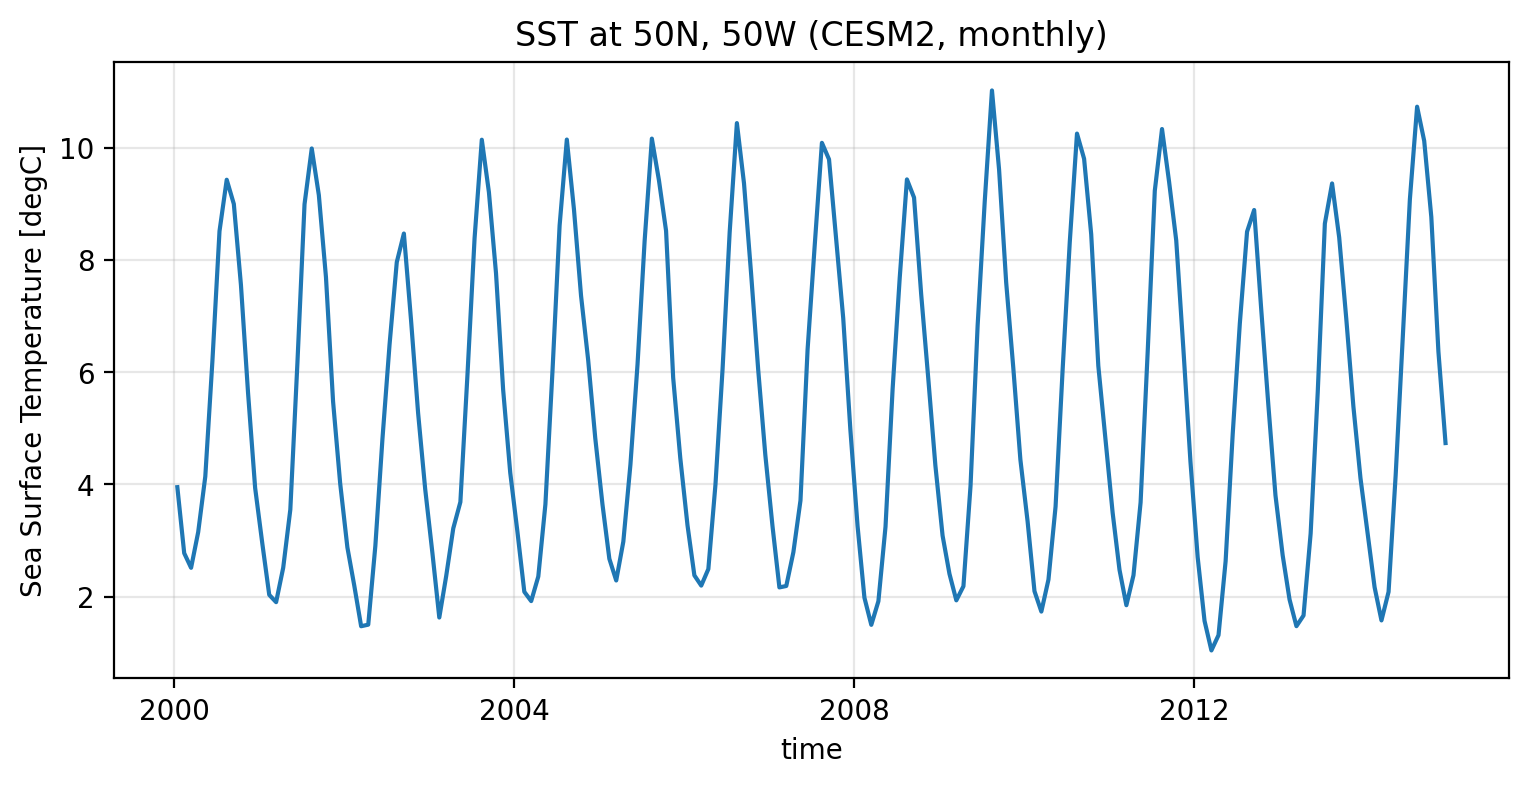

In [7]:
point = sst.sel(lon=310, lat=50, method="nearest")
print("actual grid cell used: lat =", float(point.lat), " lon =", float(point.lon))

point.plot()
plt.title("SST at 50N, 50W (CESM2, monthly)")
plt.grid(alpha=0.3)

That saw-tooth is the **seasonal cycle** -- roughly 10 degC peak to trough at
this mid-latitude site. Hold that thought; in Section 5 we separate it from
everything else in the signal.

To pull out a region, pass a `slice` to `.sel()`. Two traps to watch:

1. The slice must run in the **same direction as the coordinate**. Here `lat`
   increases from -89.5 to 89.5, so `slice(5, 25)` works and `slice(25, 5)`
   returns an empty array. (In the ERSST dataset used in Exercise 9, latitude
   runs the other way, hence `slice(30, -30)` there.)
2. Longitude here is **0 to 360**, so the Bay of Bengal is near `lon=90`, not
   `lon=-270`.

Let us take the box that matters most for Indian hydroclimatology: the northern
Indian Ocean, 5N-25N, 60E-95E -- the Arabian Sea and the Bay of Bengal, the
moisture source of the summer monsoon.

box shape (time, lat, lon): (180, 20, 35)


Text(0.5, 1.0, 'Northern Indian Ocean SST, January 2000')

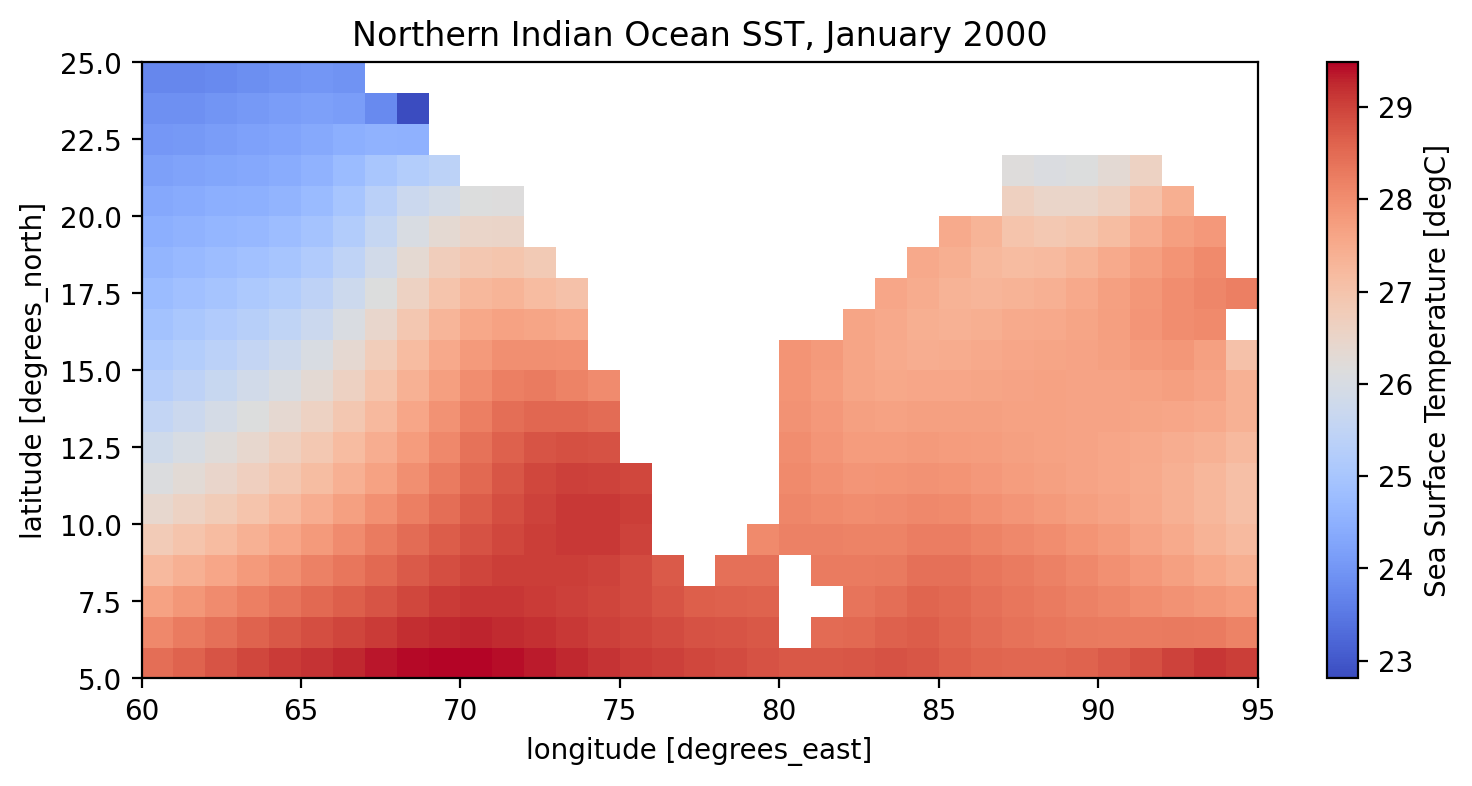

In [8]:
north_indian_ocean = sst.sel(lat=slice(5, 25), lon=slice(60, 95))
print("box shape (time, lat, lon):", north_indian_ocean.shape)

north_indian_ocean.isel(time=0).plot(cmap="coolwarm")
plt.title("Northern Indian Ocean SST, January 2000")

The white cells are **land** (India, the Arabian peninsula, Southeast Asia).
They are not zero -- they are `NaN`, "not a number", because an ocean model has
no sea surface temperature on land. This matters: every aggregation you are
about to do skips `NaN` by default, which is usually what you want but is
something you should know rather than assume.

## Section 3: Arithmetic -- vectorization

An arithmetic operation on a `DataArray` is applied to **every value at once**,
with no loop. This is called **vectorization**, and it is both far faster than a
Python loop and far easier to read.

The classic case is a unit conversion. SST is in degC; thermodynamics wants
kelvin.

In [9]:
sst_kelvin = sst + 273.15
print("degC :", float(sst.isel(time=0, lat=120, lon=310).values))
print("K    :", float(sst_kelvin.isel(time=0, lat=120, lon=310).values))

degC : 20.956764221191406
K    : 294.10675048828125


Every other operator behaves the same way -- `sst**2`, `sst / 2`, `np.log(sst)`
all return a new `DataArray` with the coordinates preserved.

```{admonition} Attributes are dropped, not converted
:class: warning
Look at `sst_kelvin.attrs` -- xarray has kept the *coordinates* but dropped the
`units` attribute, because it has no way of knowing that adding 273.15 turned
degC into kelvin. Nothing in xarray checks your units for you. If the converted
array is going anywhere else, say so explicitly.
```

In [10]:
sst_kelvin = (sst + 273.15).assign_attrs(units="K", long_name="Sea surface temperature")
sst_kelvin.attrs

{'cell_measures': 'area: areacello',
 'cell_methods': 'area: mean where sea time: mean',
 'comment': 'Model data on the 1x1 grid includes values in all cells for which ocean cells on the native grid cover more than 52.5 percent of the 1x1 grid cell. This 52.5 percent cutoff was chosen to produce ocean surface area on the 1x1 grid as close as possible to ocean surface area on the native grid, while not introducing fractional cell coverage.',
 'description': 'This may differ from "surface temperature" in regions of sea ice or floating ice shelves. For models using conservative temperature as the prognostic field, they should report the top ocean layer as surface potential temperature, which is the same as surface in situ temperature.',
 'frequency': 'mon',
 'id': 'tos',
 'long_name': 'Sea surface temperature',
 'mipTable': 'Omon',
 'out_name': 'tos',
 'prov': 'Omon ((isd.003))',
 'realm': 'ocean',
 'standard_name': 'sea_surface_temperature',
 'time': 'time',
 'time_label': 'time-mean',
 

Operations between **two** arrays are aligned on their coordinates first, not on
their position in memory. That is what makes the anomaly calculation in
Section 6 a one-liner, and it is why xarray will refuse to add two arrays on
incompatible grids rather than quietly producing nonsense -- which NumPy will
happily do whenever the shapes merely happen to match.

## Section 4: Aggregation -- reducing dimensions

An aggregation collapses one or more dimensions into a summary. The family is
`.sum()`, `.mean()`, `.median()`, `.min()`, `.max()`, `.std()`, `.var()`,
`.count()`, and they all take the same key argument: **which dimension to reduce
over**.

| call | reduces | result |
|---|---|---|
| `sst.mean()` | everything | a single number |
| `sst.mean(dim="time")` | time | a `lat` x `lon` **map** |
| `sst.mean(dim=["lat", "lon"])` | space | a **time series** |

Choosing the dimension *is* choosing the scientific question.

In [11]:
print("global, all-time mean SST :", round(float(sst.mean()), 2), "degC")
print("coldest value anywhere    :", round(float(sst.min()), 2), "degC")
print("warmest value anywhere    :", round(float(sst.max()), 2), "degC")

global, all-time mean SST : 14.25 degC
coldest value anywhere    : -1.95 degC
warmest value anywhere    : 33.76 degC


The minimum is about -1.95 degC, which is not a bug: seawater at a salinity of
35 g/kg freezes near -1.9 degC, so the polar cells sit right at the freezing
point of sea water.

Reducing over `time` gives the **mean annual SST map** -- the single most
recognisable figure in physical oceanography.

Text(0.5, 1.0, 'CESM2 mean SST, 2000-2014')

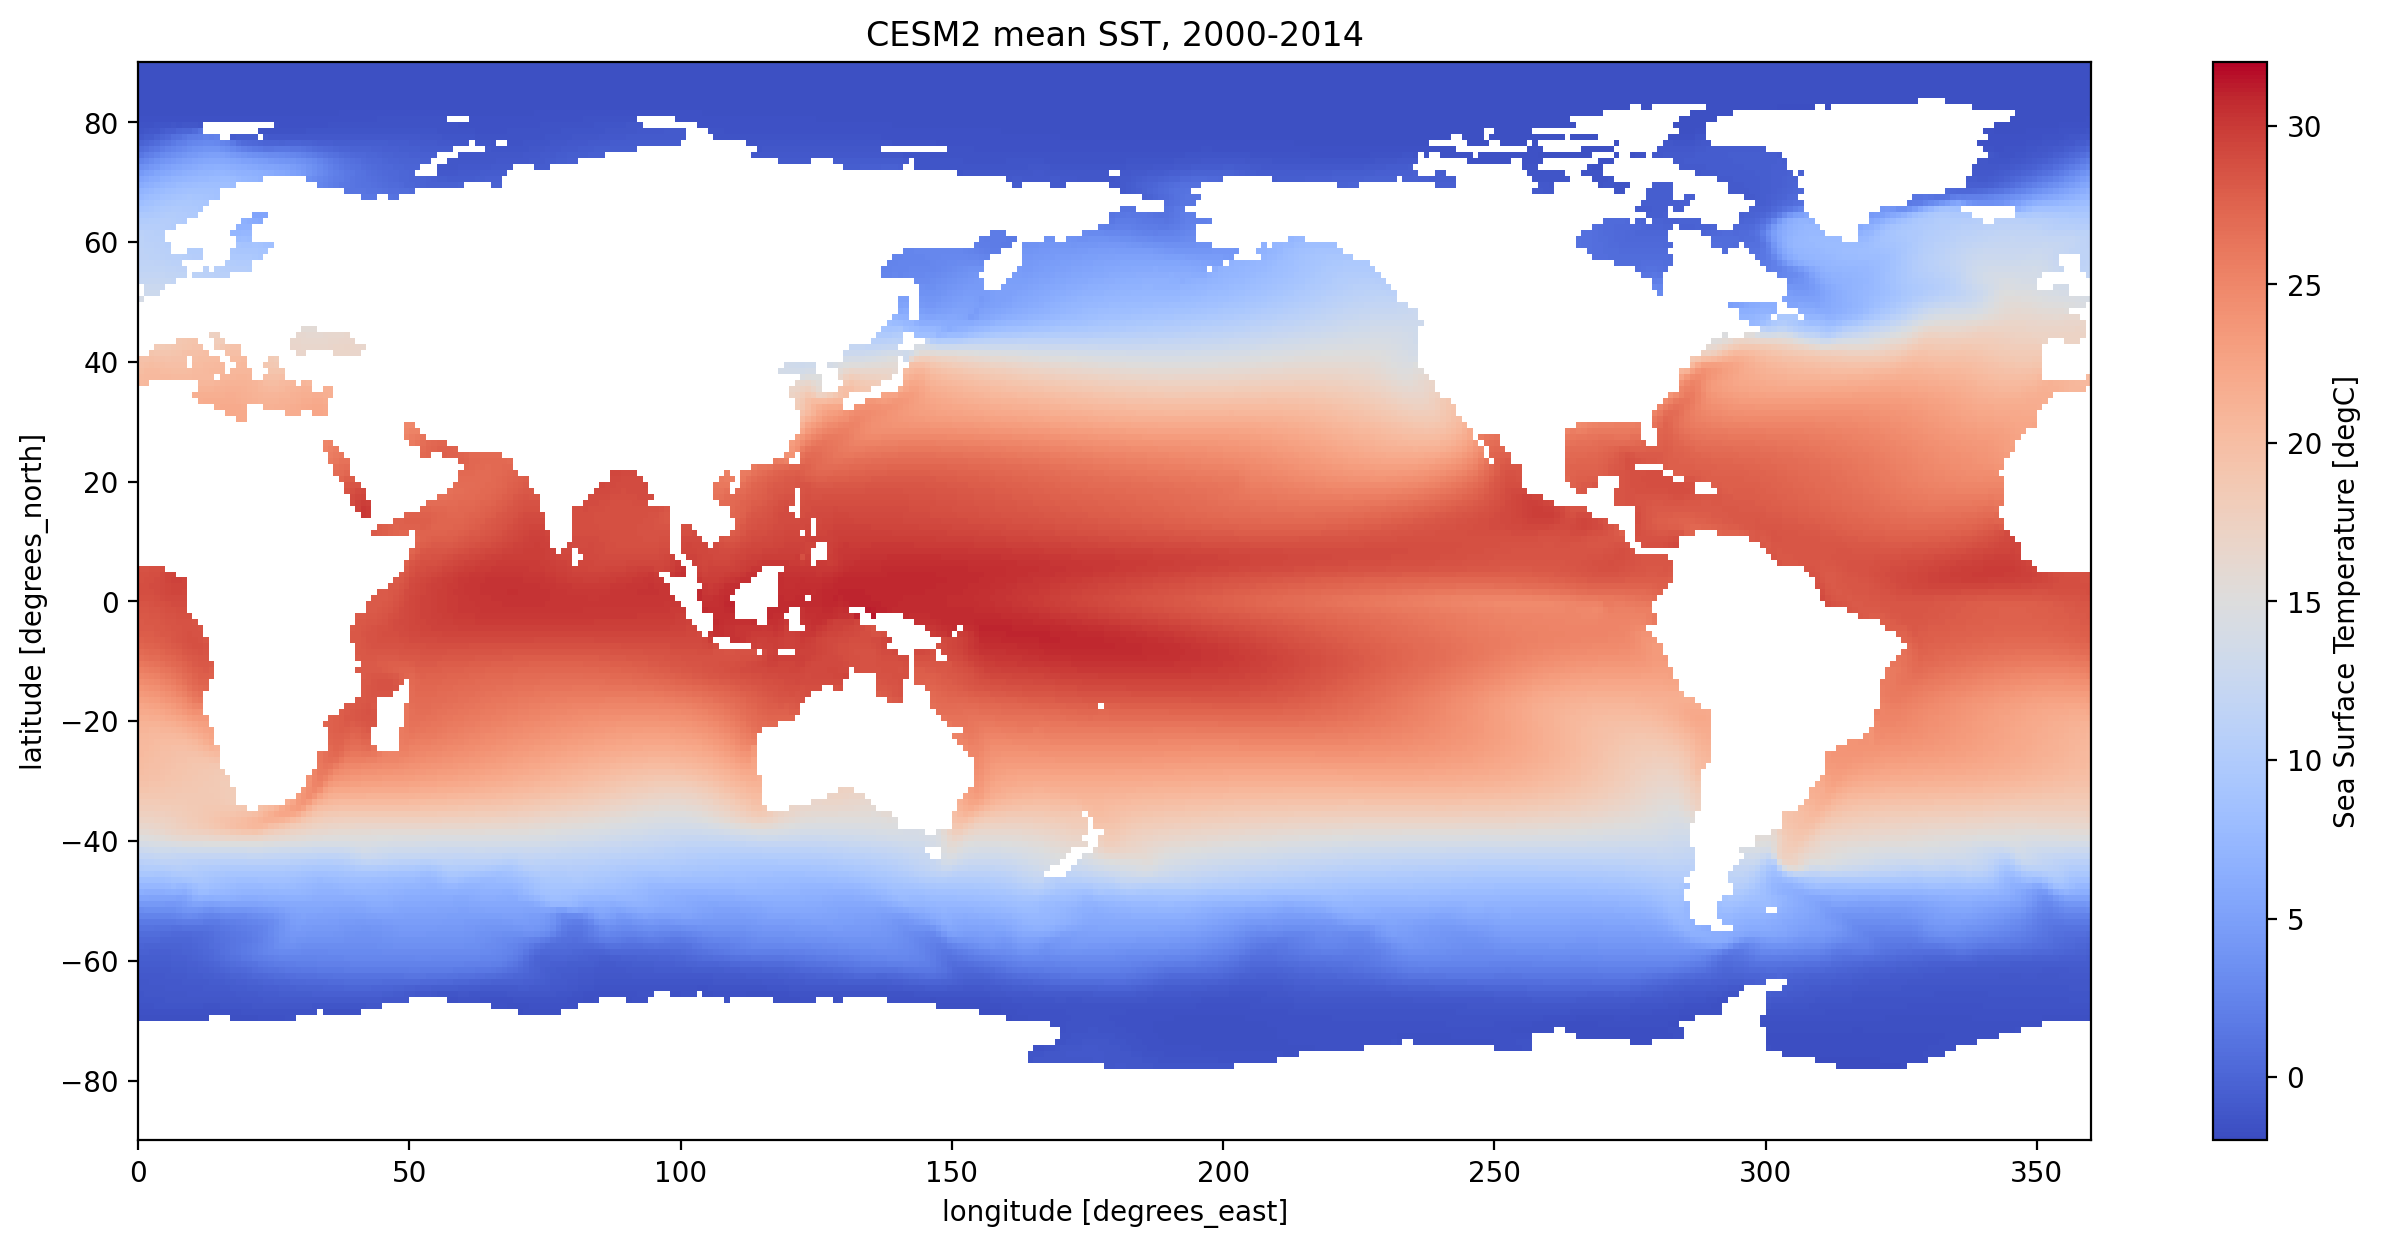

In [12]:
sst.mean(dim="time").plot(size=7, vmin=-2, vmax=32, cmap="coolwarm")
plt.title("CESM2 mean SST, 2000-2014")

```{admonition} Read the map before you move on
:class: tip
1. The dominant pattern is the **meridional gradient** -- warm equator, cold
   poles -- set by the latitude dependence of incoming solar radiation, exactly
   the cosine-of-latitude geometry from Lecture 1.
2. But the isotherms are not straight lines. Look at the **western sides** of
   the Atlantic and Pacific: warm water is dragged poleward by the Gulf Stream
   and the Kuroshio. Ocean circulation transports heat, which is the subject of
   Lecture 11.
3. Look for the cold tongues on the **eastern** sides of the tropical oceans --
   off Peru, off Namibia, off California. That is **coastal upwelling**:
   alongshore winds push surface water offshore and cold water rises to replace
   it. Those regions are also the world's driest coasts, because cold water
   suppresses evaporation and convection. SST and rainfall are the same story.
4. The warmest water on the planet is the **Indo-Pacific warm pool**, straddling
   Indonesia at above 28 degC. That is the engine of tropical convection and,
   through it, of the monsoon.
```

Now reduce over *space* instead and you get a global mean time series. Read on
before trusting it.

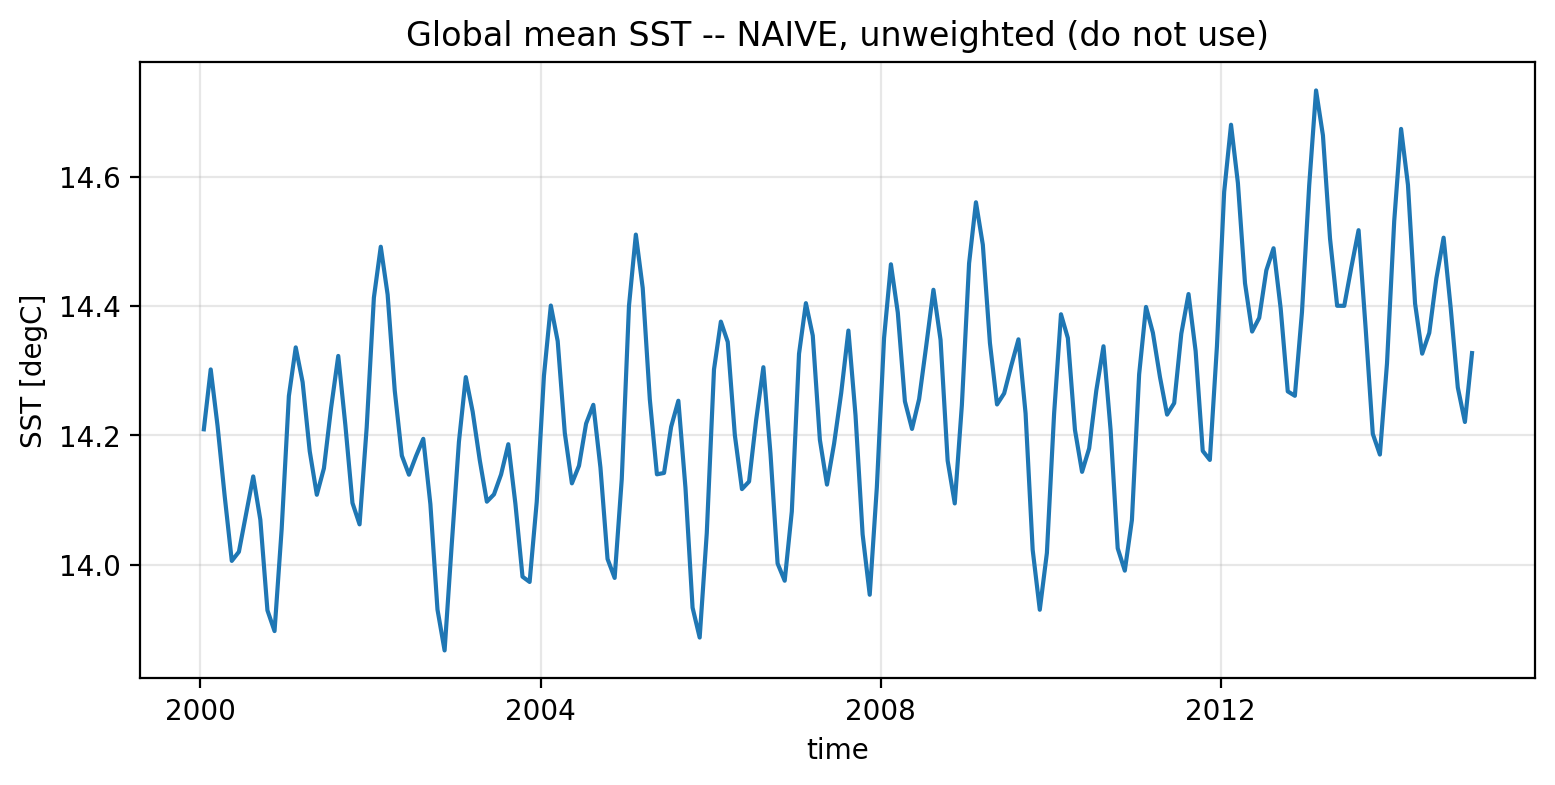

In [13]:
naive_global_mean = sst.mean(dim=["lat", "lon"])
naive_global_mean.plot()
plt.ylabel("SST [degC]")
plt.title("Global mean SST -- NAIVE, unweighted (do not use)")
plt.grid(alpha=0.3)

This curve is **wrong**, and Section 6 explains why. The reason is the single
most common error in gridded climate analysis, so it gets its own section.

## Section 5: Climatology with groupby

A **climatology** is the average seasonal cycle: the mean January, the mean
February, and so on, averaged over all the years in the record. It is the
baseline against which every anomaly is defined.

xarray computes it with the **split-apply-combine** pattern:

* **split** the 180 months into 12 groups by calendar month,
* **apply** a mean to each group,
* **combine** the 12 results into a new array with a `month` dimension.

The `.dt` accessor pulls calendar components out of the time coordinate, so
`"time.month"` is shorthand for "group by the month number of the time
coordinate".

In [14]:
sst.groupby("time.month")

<DataArrayGroupBy, grouped over 1 grouper(s), 12 groups in total:
    'month': UniqueGrouper('month'), 12/12 groups with labels 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12>

In [15]:
tos_clim = sst.groupby("time.month").mean(dim="time")
tos_clim

<xarray.DataArray 'tos' (month: 12, lat: 180, lon: 360)> Size: 3MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.780786 , -1.780688 , -1.7805718, ..., -1.7809757,
         -1.7809197, -1.7808627],
        [-1.7745041, -1.7744204, -1.7743237, ..., -1.77467  ,
         -1.774626 , -1.7745715],
        [-1.7691481, -1.7690798, -1.7690051, ..., -1.7693441,
         -1.7692844, -1.7692182]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [-1.7605033, -1.760397 , -1.7602725, ..., -1.760718 ,
         -1.7606541, -1.7605885],
        [-1.7544289, -1.7543424, -1.7542422, ..., -1.754608 ,
         -1.754559 , -1.7545002],
        [-1.7492163, -1.749148 , -1.7490736, ..., -1.7494118,
         -1.7493519, -1.7492864]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.7711828, -1.7710832, -1.7709653, ..., -1.7713748,
         -1.7713183, -1.7712607],
        [-1.7648666, -1.7647841, -1.7646879, ..., -1.7650299,
         -1.7649865, -1.7649331],
        [-1.759478 , -1.7594113, -1.7593384, ..., -1.7596704,
         -1.7596117, -1.759547 ]]], shape=(12, 180, 360), dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

Note the shape: `(month: 12, lat: 180, lon: 360)`. The `time` dimension of
length 180 has become a `month` dimension of length 12 -- each of the 15
Januaries in the record has been averaged into one.

Here is the climatology at our North Atlantic point: the clean seasonal cycle
underneath the noisy time series from Section 2.

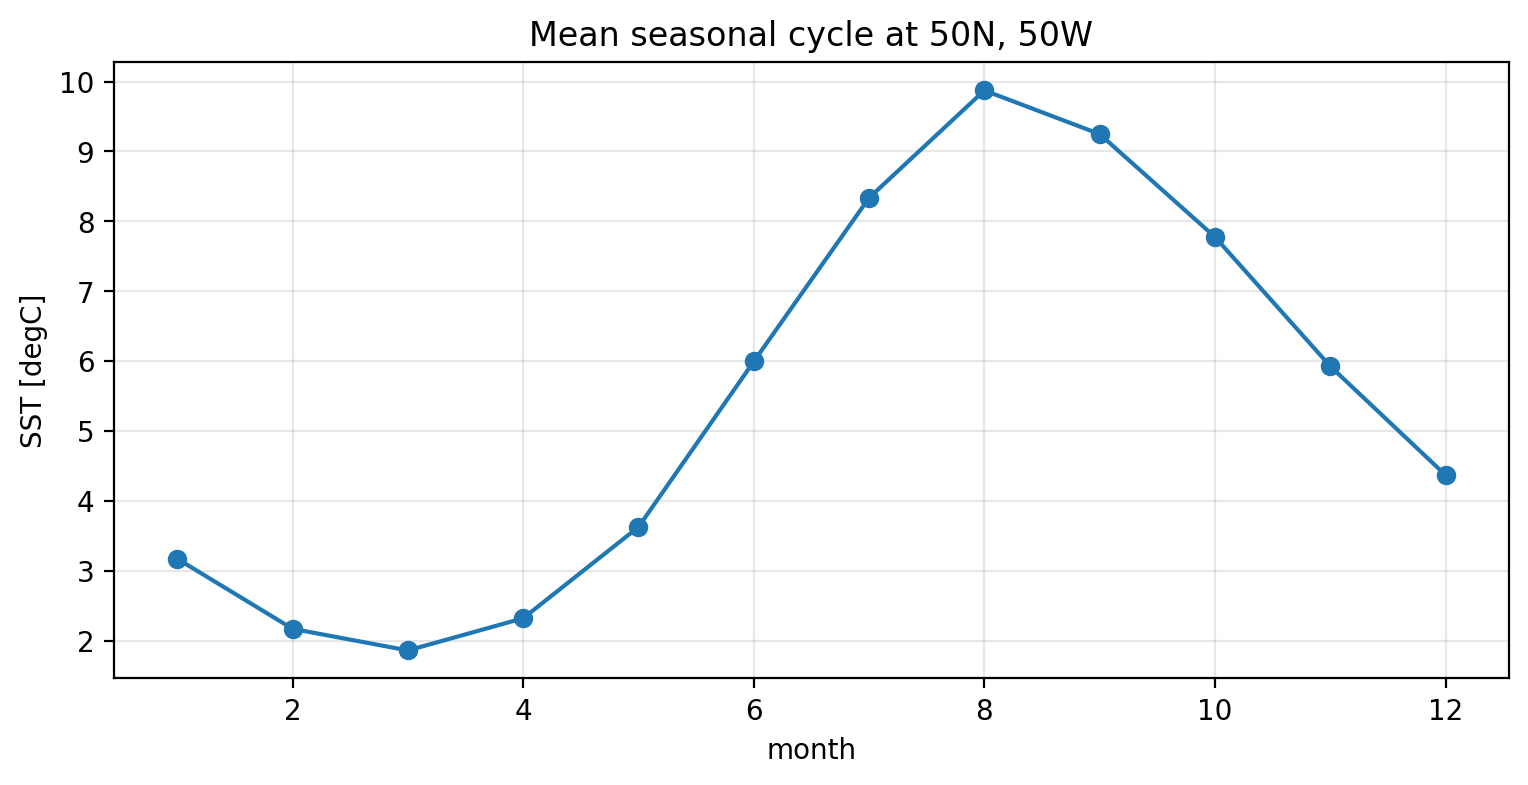

In [16]:
tos_clim.sel(lon=310, lat=50, method="nearest").plot(marker="o")
plt.ylabel("SST [degC]")
plt.title("Mean seasonal cycle at 50N, 50W")
plt.grid(alpha=0.3)

The peak is in **August-September**, not June, and the minimum in
**February-March**, not December. That two-to-three month lag behind the
solstice is **thermal inertia**: the large heat capacity of the ocean mixed
layer means the surface keeps warming as long as the net heat flux is positive,
not only while insolation is rising. You met the same lag in the energy-balance
models of Lectures 4 and 5, and it is why the hottest month at a coastal station
is not the month of maximum sun.

To see the seasonal cycle everywhere at once, average out longitude and plot
month against latitude.

Text(0.5, 0, 'month')

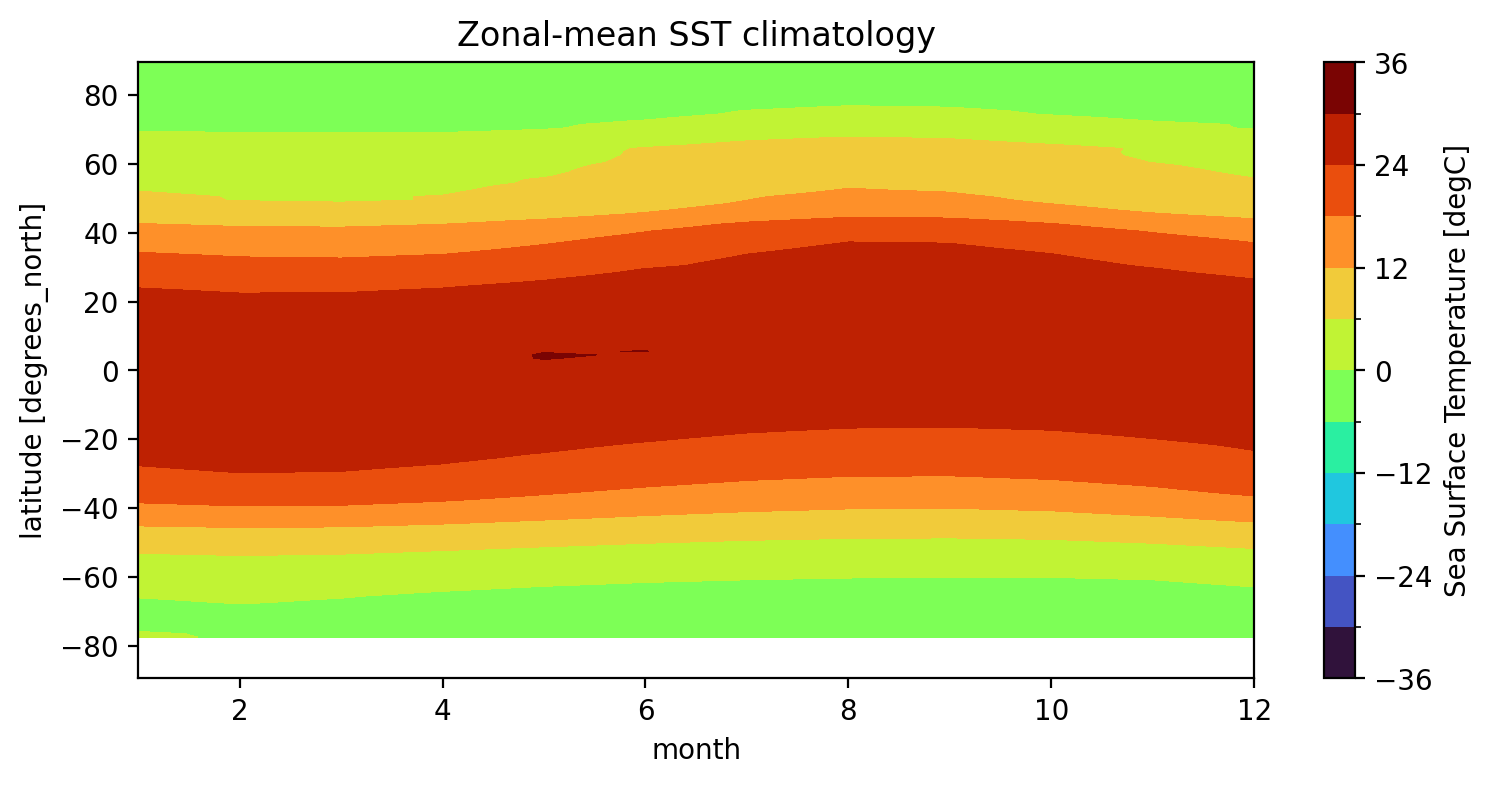

In [17]:
tos_clim.mean(dim="lon").transpose().plot.contourf(levels=12, cmap="turbo")
plt.title("Zonal-mean SST climatology")
plt.xlabel("month")

Two things to read here. First, the **seasonal swing is large at high latitudes
and almost absent at the equator** -- the tropics have no meaningful seasons in
temperature, which is why tropical climate is classified by *rainfall* seasons
instead (Koppen, Lecture 2). Second, the warm band shifts north in
July-September and south in January-March. That migration of the thermal equator
is what drags the **ITCZ**, and the monsoon rain belt, with it.

The blunt way to see the same thing is January minus July.

Text(0.5, 1.0, 'SST climatology: January minus July [degC]')

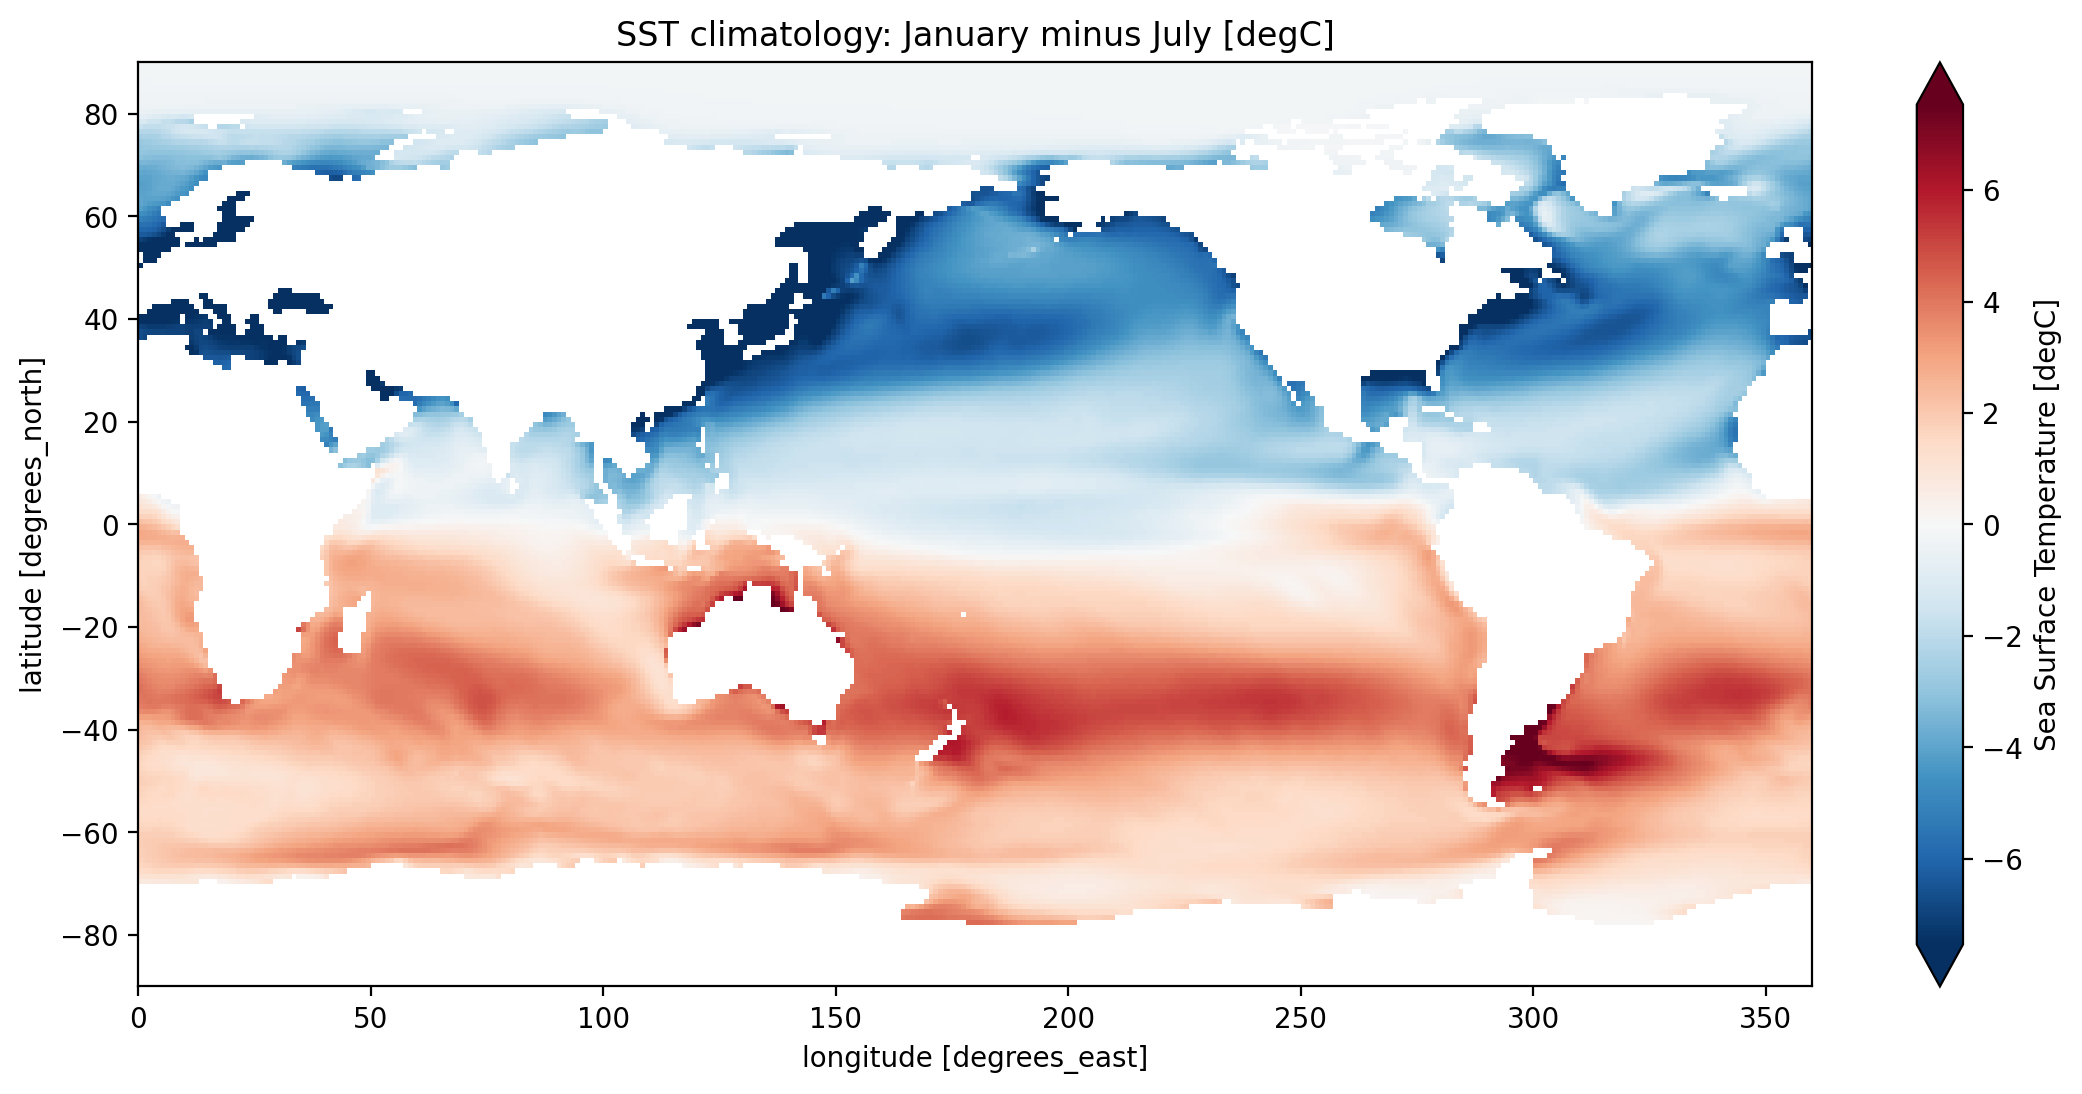

In [18]:
(tos_clim.sel(month=1) - tos_clim.sel(month=7)).plot(size=6, robust=True)
plt.title("SST climatology: January minus July [degC]")

Blue means July is warmer (northern hemisphere); red means January is warmer
(southern hemisphere). The amplitude is far larger over the northern oceans,
because the northern hemisphere has more land and less ocean to buffer it.

Note `robust=True`: it sets the colour limits to the 2nd and 98th percentiles
instead of the full range, so a handful of extreme cells cannot wash out the
whole map. It is a good default for any field with outliers.

## Section 6: Anomalies, and why you must weight by area

### Section 6.1: The anomaly

An **anomaly** is the departure from the climatology: how unusual was this
particular January, compared with a typical January? Subtracting the seasonal
cycle removes the largest and least interesting signal in the data, and exposes
the interannual variability and the trend underneath.

In xarray this is arithmetic between a grouped object and the climatology. The
alignment happens by label, so each month is matched with its own baseline.

In [19]:
gb = sst.groupby("time.month")
tos_clim = gb.mean(dim="time")
tos_anom = gb - tos_clim          # each month minus its own climatology
tos_anom

<xarray.DataArray 'tos' (time: 180, lat: 180, lon: 360)> Size: 47MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-0.01402271, -0.01401687, -0.01401365, ..., -0.01406252,
         -0.01404917, -0.01403356],
        [-0.01544118, -0.01544476, -0.01545036, ..., -0.0154475 ,
         -0.01544321, -0.01544082],
        [-0.01638114, -0.01639009, -0.01639998, ..., -0.01635301,
         -0.01636147, -0.01637137]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [ 0.01727939,  0.01713431,  0.01698041, ...,  0.0176847 ,
          0.01755834,  0.01742125],
        [ 0.0173862 ,  0.0172919 ,  0.01719594, ...,  0.01766813,
          0.01757395,  0.01748013],
        [ 0.01693714,  0.01687253,  0.01680517, ...,  0.01709175,
          0.0170424 ,  0.01699162]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.01506364,  0.01491845,  0.01476014, ...,  0.01545238,
          0.0153321 ,  0.01520228],
        [ 0.0142287 ,  0.01412642,  0.01402068, ...,  0.0145216 ,
          0.01442552,  0.01432824],
        [ 0.01320827,  0.01314461,  0.01307774, ...,  0.0133611 ,
          0.0133127 ,  0.01326215]]], shape=(180, 180, 360), dtype=float32)
Coordinates:
  * time     (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
    month    (time) int64 1kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

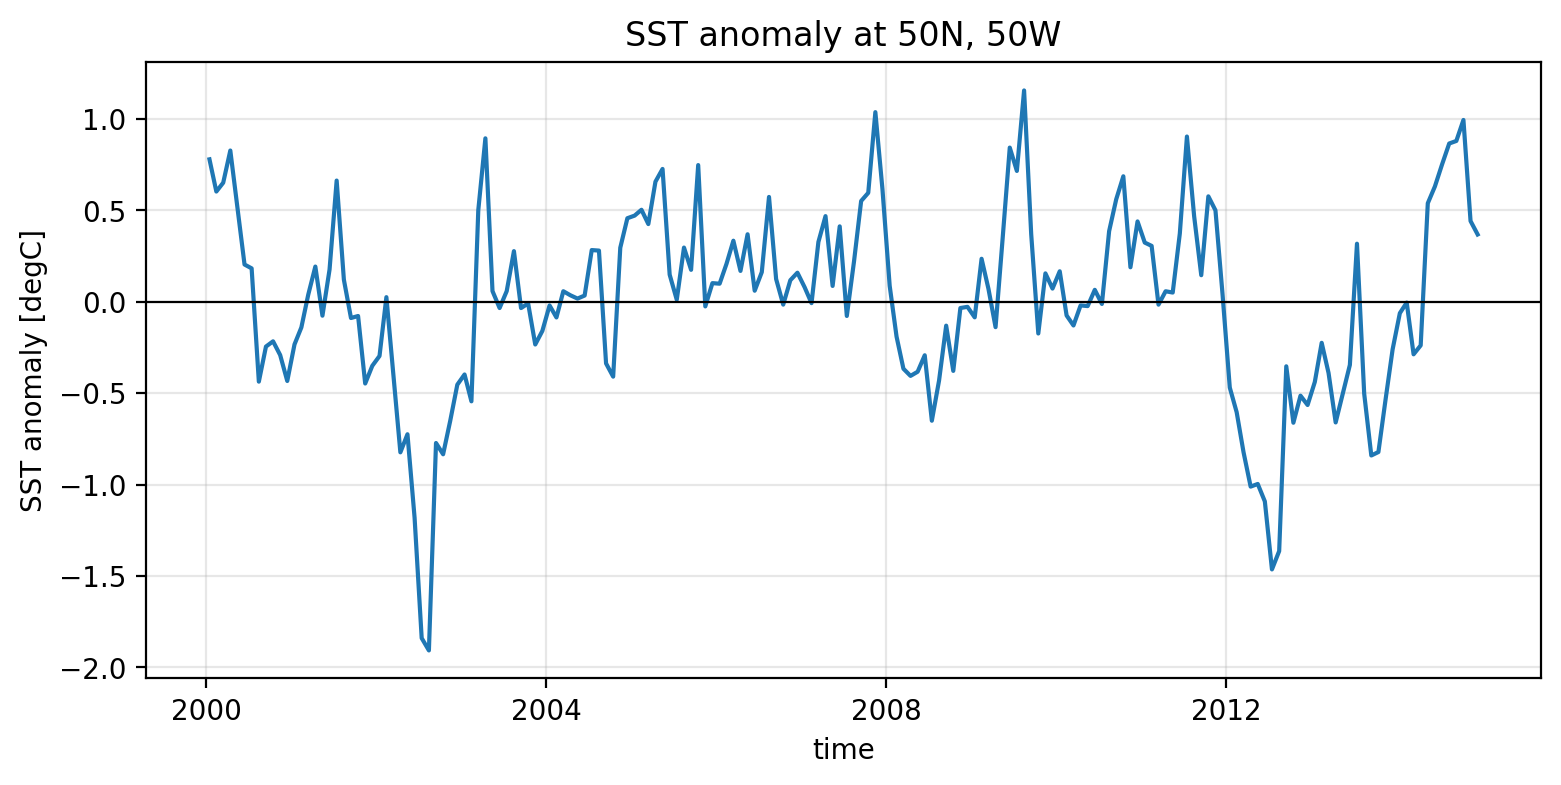

In [20]:
tos_anom.sel(lon=310, lat=50, method="nearest").plot()
plt.axhline(0, color="k", lw=0.8)
plt.ylabel("SST anomaly [degC]")
plt.title("SST anomaly at 50N, 50W")
plt.grid(alpha=0.3)

Compare this with the raw series in Section 2. The 10 degC saw-tooth is gone;
what is left is a roughly +/- 1.5 degC wobble. That residual is the actual
year-to-year climate signal at this location.

### Section 6.2: The area weighting problem

Now back to that "wrong" global mean. On a regular latitude-longitude grid,
**cells are not equal in area**. A 1 degree x 1 degree cell at the equator is
about 111 km x 111 km; at 60N it is 111 km x 55 km; near the pole it shrinks to
nothing. A plain `.mean(dim=["lat","lon"])` treats all of them as equal, which
massively over-weights the polar cells -- and the poles are exactly where the
anomalies are largest.

There are two correct ways to fix this.

**Option A -- use the model's own cell areas.** CMIP6 ships an `areacello`
field giving the true area of every ocean cell in m^2. This is the most accurate
choice, since it also accounts for the land mask and any grid distortion.

In [21]:
filepath2 = DATASETS.fetch("CESM2_grid_variables.nc")
areacello = xr.open_dataset(filepath2).areacello
areacello

<xarray.DataArray 'areacello' (lat: 180, lon: 360)> Size: 518kB
[64800 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/17)
    cell_methods:   area: sum
    comment:        TAREA
    description:    Cell areas for any grid used to report ocean variables an...
    frequency:      fx
    id:             areacello
    long_name:      Grid-Cell Area for Ocean Variables
    ...             ...
    time_label:     None
    time_title:     No temporal dimensions ... fixed field
    title:          Grid-Cell Area for Ocean Variables
    type:           real
    units:          m2
    variable_id:    areacello

In [22]:
weighted_mean_global_anom = tos_anom.weighted(areacello).mean(dim=["lat", "lon"])

**Option B -- use cosine-of-latitude weights.** When you do not have a cell-area
file, the area of a lat-lon cell is proportional to $\cos\phi$, and that
approximation is essentially free.

In [23]:
coslat = np.cos(np.deg2rad(sst["lat"]))
coslat_mean_global_anom = tos_anom.weighted(coslat).mean(dim=["lat", "lon"])

unweighted_mean_global_anom = tos_anom.mean(dim=["lat", "lon"])

std dev, unweighted : 0.117 degC
std dev, areacello  : 0.1443 degC
std dev, cos(lat)   : 0.1443 degC


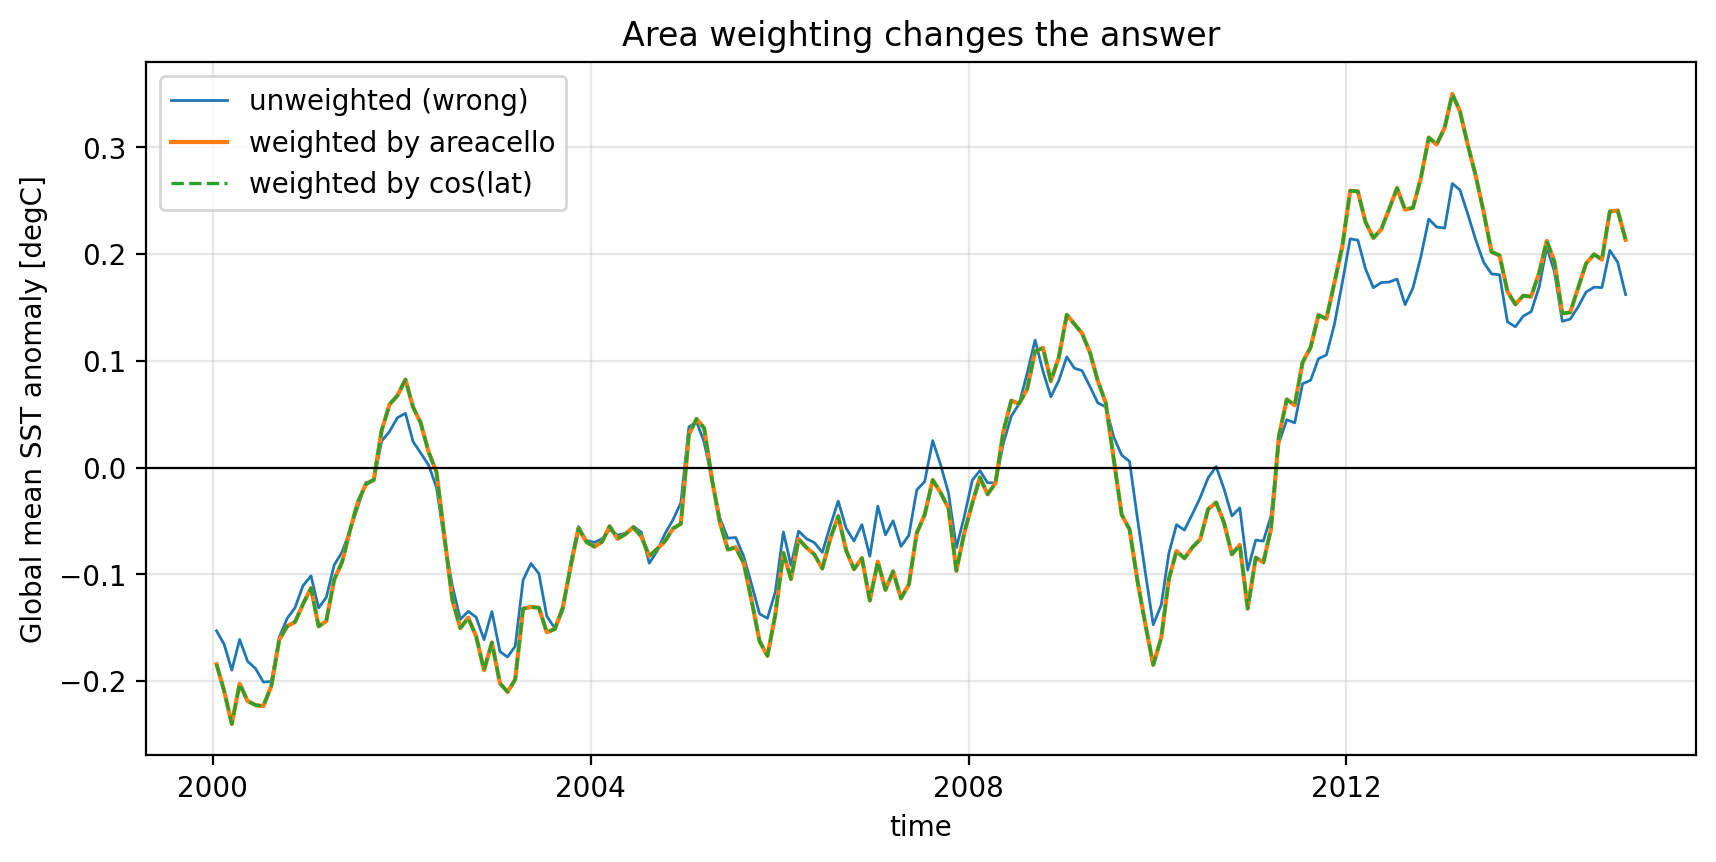

In [24]:
plt.figure(figsize=(10, 4.5))
unweighted_mean_global_anom.plot(label="unweighted (wrong)", lw=1)
weighted_mean_global_anom.plot(label="weighted by areacello", lw=1.5)
coslat_mean_global_anom.plot(label="weighted by cos(lat)", ls="--", lw=1.2)
plt.axhline(0, color="k", lw=0.8)
plt.legend()
plt.ylabel("Global mean SST anomaly [degC]")
plt.title("Area weighting changes the answer")
plt.grid(alpha=0.3)

print("std dev, unweighted :", round(float(unweighted_mean_global_anom.std()), 4), "degC")
print("std dev, areacello  :", round(float(weighted_mean_global_anom.std()), 4), "degC")
print("std dev, cos(lat)   :", round(float(coslat_mean_global_anom.std()), 4), "degC")

Read the numbers. The two weighted curves are **indistinguishable** -- standard
deviations of 0.1443 and 0.1443 degC -- which tells you the cheap $\cos\phi$
approximation is perfectly good on this grid. The unweighted curve is a
different series altogether, with a standard deviation of 0.1170 degC, about
**19% too small**, and a visibly different shape.

```{admonition} The rule
:class: important
Never take an unweighted spatial mean of a lat-lon grid. If a global or regional
average appears in your report and you cannot point to the line that weighted
it, the number is wrong. The same applies to basin-average rainfall and to
catchment-average anything.
```

## Section 7: Resampling, rolling means and coarsening

Three different operations reduce along time, and they are routinely mixed up.

* **`.resample()`** changes the *sampling frequency* to calendar-aligned bins.
  Monthly to annual turns 180 values into 15. Non-overlapping.
* **`.rolling()`** slides a window over the data and returns an array of the
  *same length*, smoothed. Overlapping.
* **`.coarsen()`** blocks together a fixed *number of points* along any
  dimension, including space. Non-overlapping and calendar-unaware.

In [25]:
# resample monthly -> annual. "YS" = year start.
annual_mean = sst.resample(time="YS").mean()
annual_mean_global = annual_mean.weighted(coslat).mean(dim=["lat", "lon"])
print("180 months ->", annual_mean.sizes["time"], "years")

180 months -> 15 years


```{admonition} "AS" versus "YS"
:class: note
Older tutorials -- including the ClimateMatch original -- write
`resample(time="AS")`. Pandas has deprecated that alias; current xarray emits a
`FutureWarning` and wants **`"YS"`**. Other useful codes: `"MS"` month start,
`"QS-DEC"` seasons starting in December (DJF/MAM/JJA/SON), `"D"` daily.
```

In [26]:
# rolling: 6-month centred moving average, same length as the original
tos_m_avg = sst.rolling(time=6, center=True).mean()
tos_m_avg_global = tos_m_avg.weighted(coslat).mean(dim=["lat", "lon"])
print("rolling output length:", tos_m_avg.sizes["time"], "(unchanged)")

rolling output length: 180 (unchanged)


In [27]:
# coarsen in time only: average blocks of 4 consecutive months
coarse_time = sst.coarsen(time=4).mean()
coarse_time_global = coarse_time.weighted(coslat).mean(dim=["lat", "lon"])
print("coarsened in time :", coarse_time.shape, "-> 180 / 4 = 45 blocks")

# coarsen can block space too. lat=len(ds.lat) puts every latitude in ONE block,
# collapsing the whole map to a single column:
coarse_all = sst.coarsen(time=4, lat=len(ds.lat), lon=len(ds.lon)).mean()
print("coarsened in time and space:", coarse_all.shape, "-> (time, 1, 1)")
print("...but that spatial mean is UNWEIGHTED:",
      round(float(coarse_all.mean()), 2), "degC vs",
      round(float(coarse_time_global.mean()), 2), "degC weighted")

coarsened in time : (45, 180, 360) -> 180 / 4 = 45 blocks


coarsened in time and space: (45, 1, 1) -> (time, 1, 1)
...but that spatial mean is UNWEIGHTED: 14.25 degC vs 18.82 degC weighted


Look at those last two numbers: collapsing the map with `.coarsen()` gives a
"global mean" of 14.25 degC, while the properly weighted mean is 18.82 degC --
a **4.5 degC** error, from exactly the Section 6 bug. `.coarsen()` divides by the
number of cells, and it has no idea that a polar cell is a sliver and an
equatorial cell is not. Use coarsening to block in time or to regrid; never to
take a global mean.

So for the comparison below we coarsen in *time* and then take a *weighted*
spatial mean, which puts all four curves on a like-for-like footing.

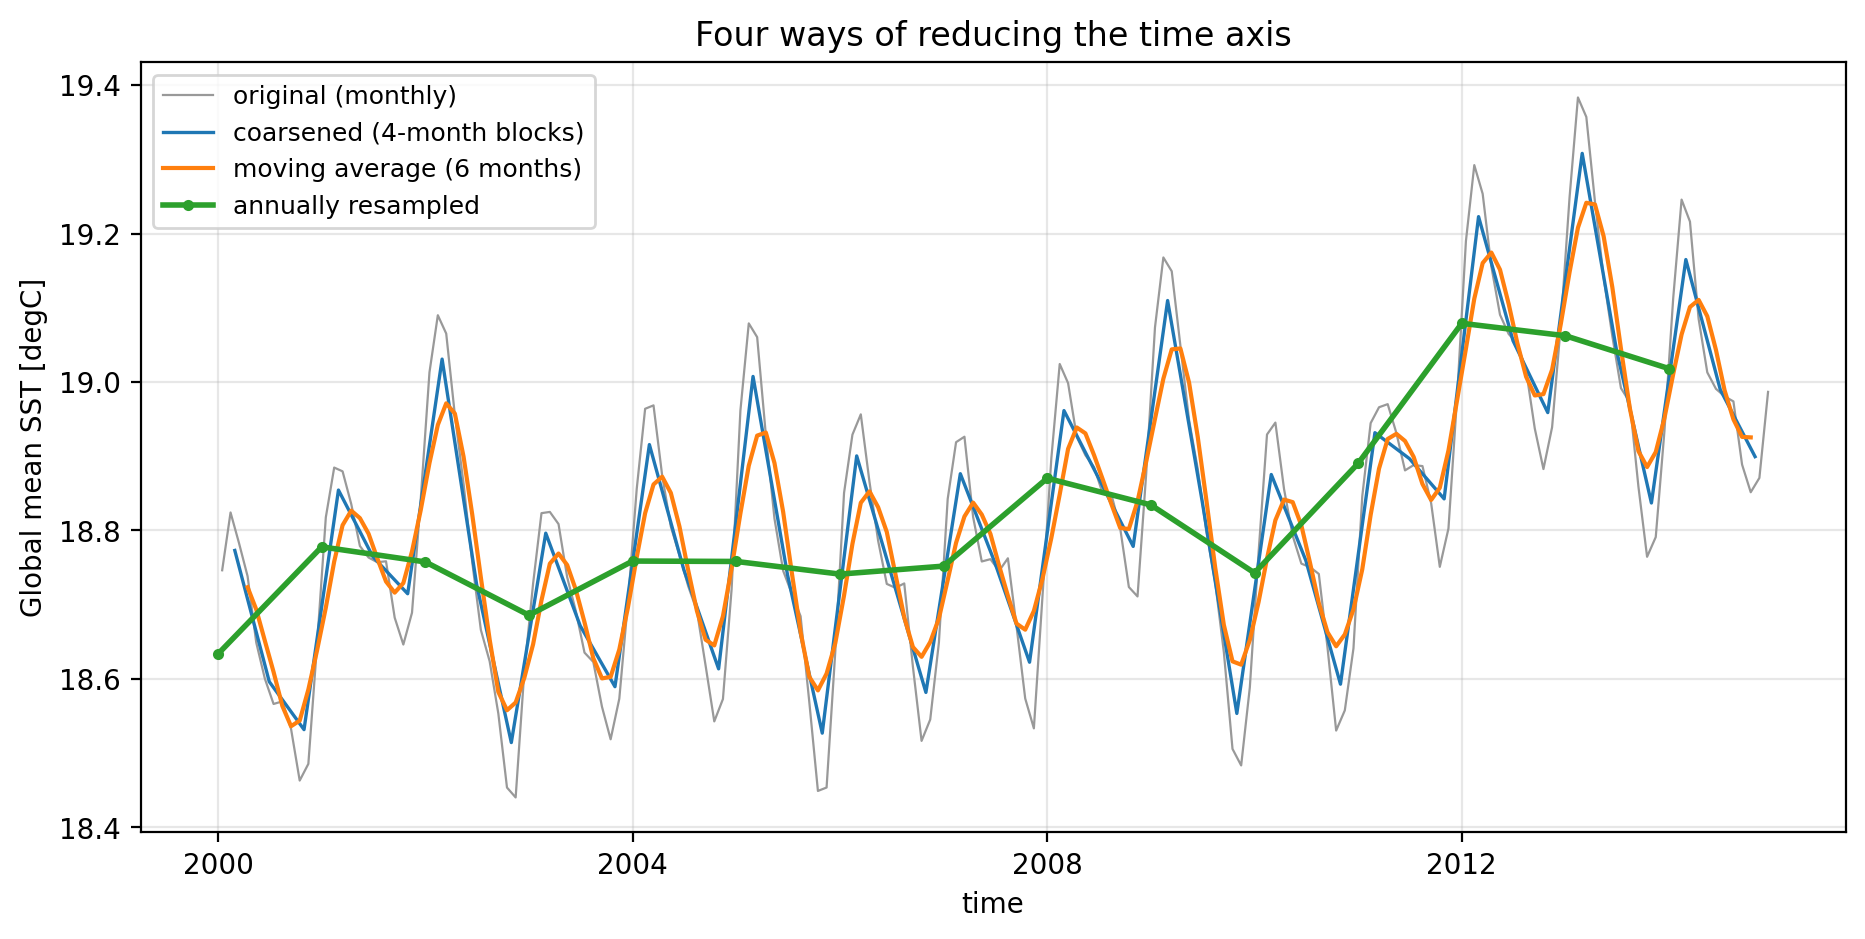

In [28]:
original_global = sst.weighted(coslat).mean(dim=["lat", "lon"])

plt.figure(figsize=(11, 5))
original_global.plot(label="original (monthly)", lw=0.8, color="0.6")
coarse_time_global.plot(label="coarsened (4-month blocks)", lw=1.2)
tos_m_avg_global.plot(label="moving average (6 months)", lw=1.5)
annual_mean_global.plot(label="annually resampled", lw=2, marker="o", ms=3)
plt.legend(fontsize=9)
plt.ylabel("Global mean SST [degC]")
plt.title("Four ways of reducing the time axis")
plt.grid(alpha=0.3)

The grey curve swings by close to a degree (18.44 to 19.38 degC) every single
year. That is the seasonal cycle of the *global* mean, and it exists only
because the hemispheres are not symmetric: the northern hemisphere has far more
land, so the planet's ocean surface is warmest during northern summer.

Each of the other three is a **low-pass filter**, and they differ in how hard
they cut. The 4-month coarsening barely touches the seasonal cycle. The 6-month
rolling mean knocks it down but leaves a visible ripple, because a 6-month
window only half-averages a 12-month oscillation. The annual mean removes it
essentially completely, leaving a range of just 18.63 to 19.08 degC -- the
interannual signal, which is what you would actually fit a trend to, as we do in
Section 9.

This is a genuine analysis decision, not cosmetics. Smooth too little and the
seasonal cycle drowns your trend; smooth too much and you erase the event you
were looking for.

## Section 8: Masking with .where()

Often you want to keep only the part of a field that satisfies a condition --
sea ice, land, the tropics, cells above a threshold. That is **masking**, and
the tool is `.where(condition)`: values where the condition is `True` are kept,
everything else becomes `NaN`.

The key point is that the **shape does not change**. Masking is not filtering;
you keep the grid and blank out cells, which is what lets you keep plotting maps
and lets aggregations skip the blanked cells automatically.

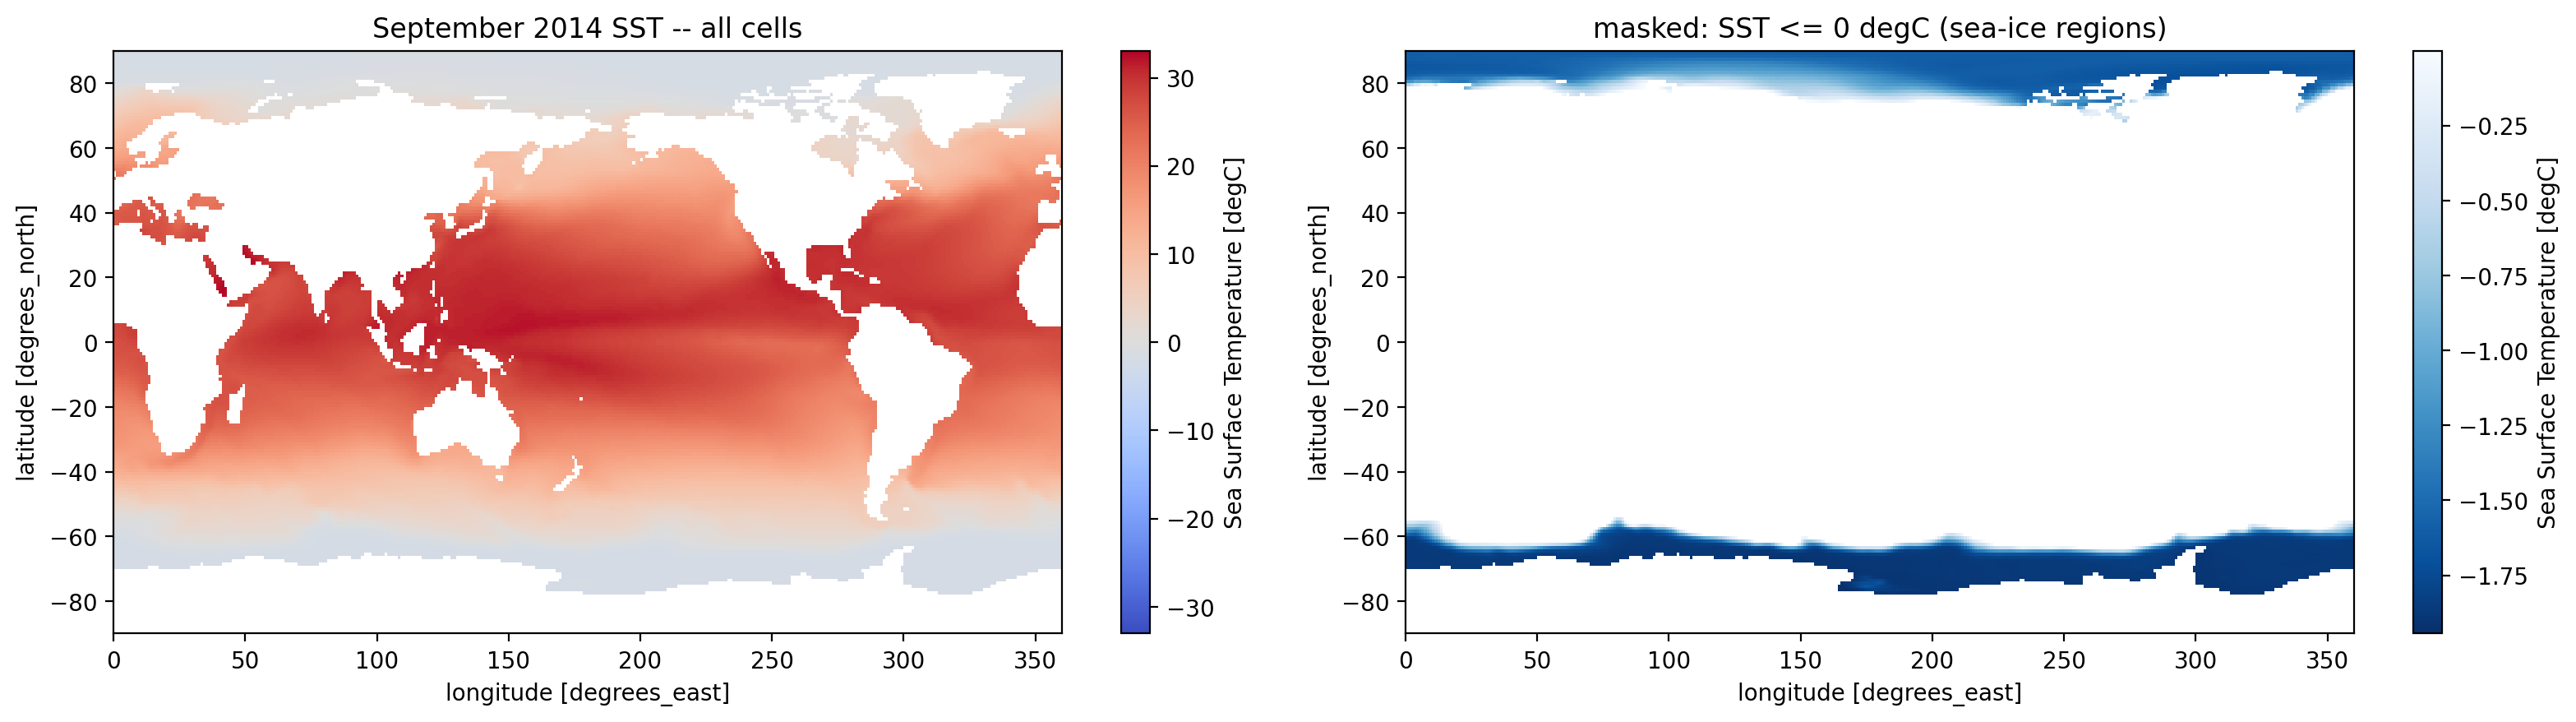

In [29]:
sample = sst.sel(time="2014-09").squeeze()
freezing = sample.where(sample <= 0.0)

fig, axes = plt.subplots(ncols=2, figsize=(16, 4.5))
sample.plot(ax=axes[0], cmap="coolwarm")
axes[0].set_title("September 2014 SST -- all cells")
freezing.plot(ax=axes[1], cmap="Blues_r")
axes[1].set_title("masked: SST <= 0 degC (sea-ice regions)")
plt.tight_layout()

The right panel is, in effect, a **sea-ice map** derived from temperature alone:
the only ocean at or below 0 degC is polar water sitting at its freezing point.
September is the end of the northern melt season and the end of the southern
growth season, which is why Antarctica is so much better covered than the
Arctic.

### Section 8.1: Several conditions at once

Combine conditions with `&` (and), `|` (or) and `~` (not). Use the **bitwise**
operators, not Python's `and`/`or`, and **bracket every term** -- `&` binds more
tightly than `>`, so a missing bracket is a `TypeError` at best and a wrong
answer at worst.

The band above 28 degC is worth isolating: that is roughly the SST threshold for
deep atmospheric convection, so it marks the regions capable of driving heavy
tropical rainfall.

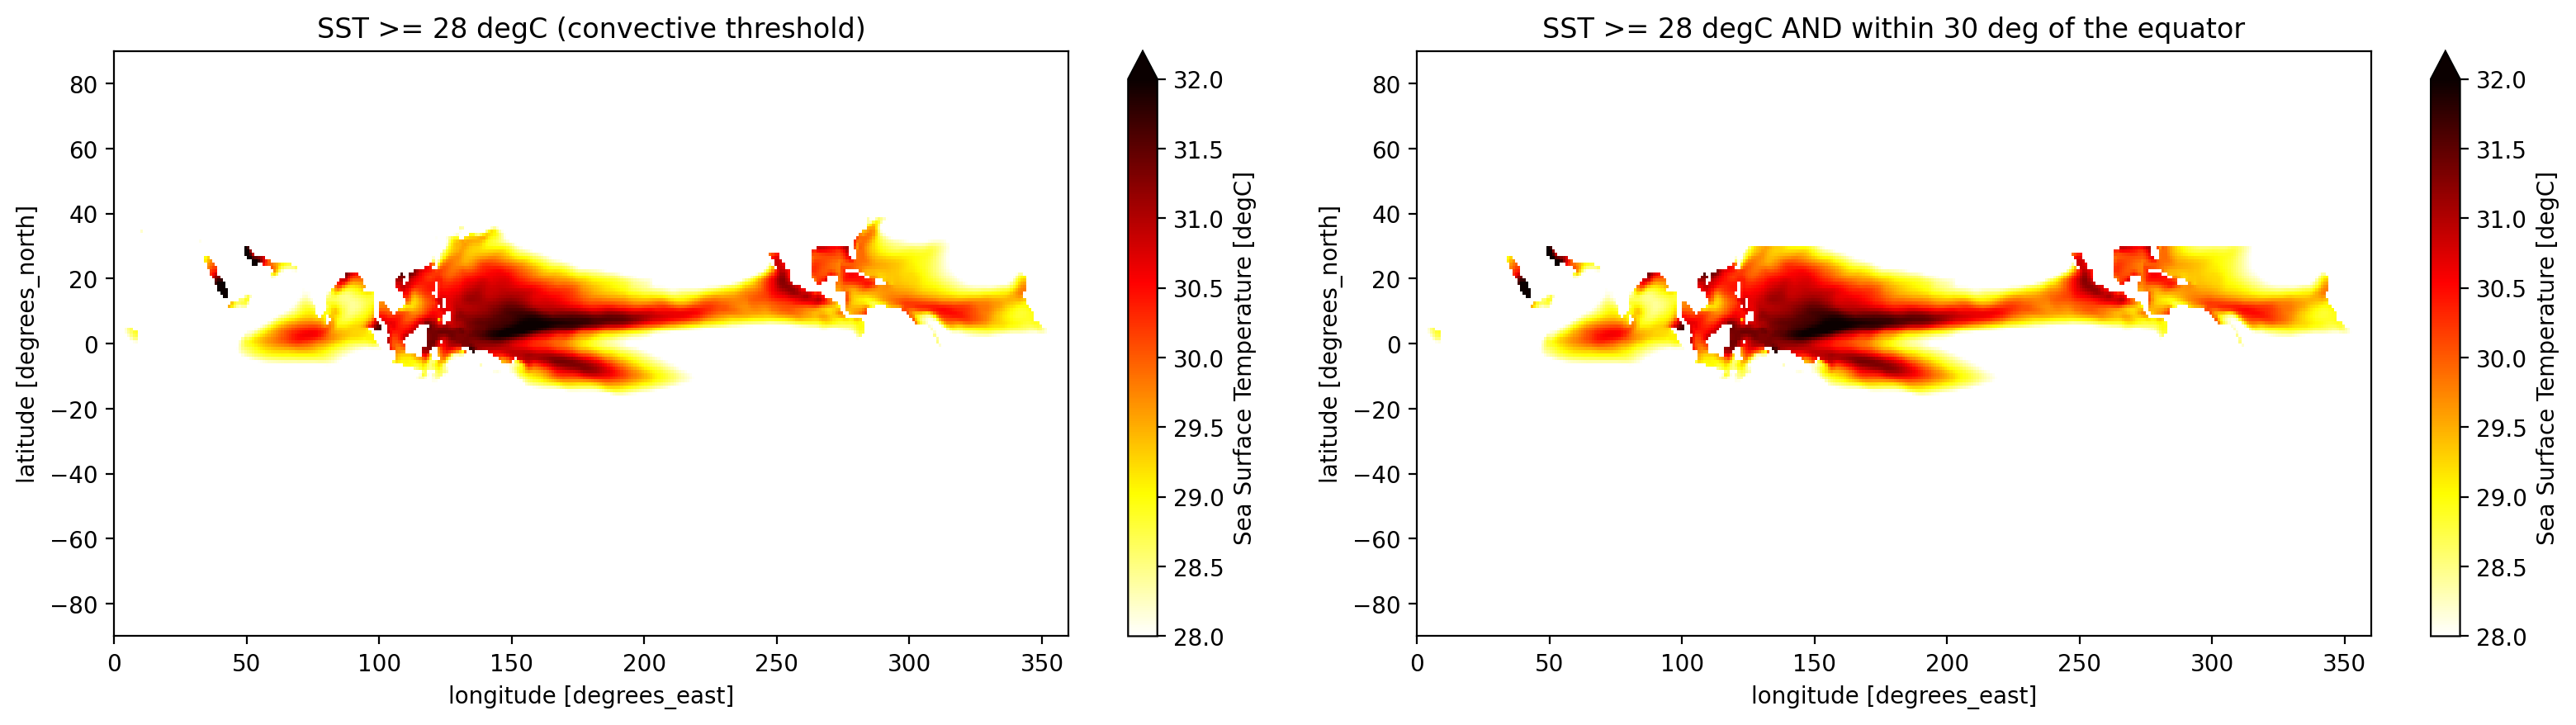

In [30]:
warm_pool = sample.where(sample >= 28.0)
tropical_band = sample.where((sample >= 28.0) & (sample.lat > -30) & (sample.lat < 30))

fig, axes = plt.subplots(ncols=2, figsize=(16, 4.5))
warm_pool.plot(ax=axes[0], vmin=28, vmax=32, cmap="hot_r")
axes[0].set_title("SST >= 28 degC (convective threshold)")
tropical_band.plot(ax=axes[1], vmin=28, vmax=32, cmap="hot_r")
axes[1].set_title("SST >= 28 degC AND within 30 deg of the equator")
plt.tight_layout()

Masks are also how you *quantify* a region rather than just look at it. Because
`NaN` cells are skipped, `.count()` gives you the number of surviving cells --
though if you want an **area**, you must weight, for exactly the Section 6
reason.

In [31]:
ocean_cells = int(sample.notnull().sum())
warm_cells = int(warm_pool.notnull().sum())
print(f"ocean cells               : {ocean_cells}")
print(f"cells at or above 28 degC : {warm_cells}  ({100*warm_cells/ocean_cells:.1f}% of cells)")

# the honest version: fraction of ocean AREA above the threshold
area_frac = float(areacello.where(sample >= 28.0).sum() / areacello.where(sample.notnull()).sum())
print(f"fraction of ocean AREA >= 28 degC : {100*area_frac:.1f}%")

ocean cells               : 42491
cells at or above 28 degC : 7369  (17.3% of cells)
fraction of ocean AREA >= 28 degC : 24.4%


Note the gap between the two numbers. Counting cells says one thing; weighting
by area says another, because the warm cells are all tropical and tropical cells
are the big ones. The area-weighted figure is the one you would report.

## Section 9: Trend analysis

Section 7 ended with an annual-mean curve and the remark that this is "what you
would actually fit a trend to". Now we fit one -- carefully, because trend
estimation is where climate and hydrology papers most often go wrong.

### Section 9.0: What a trend is, and what it is not

Start with the decomposition that underlies every method in this section. Any
climate series can be written as

$$ y(t) \;=\; \underbrace{T(t)}_{\text{trend}} \;+\; \underbrace{S(t)}_{\text{seasonal cycle}} \;+\; \underbrace{\varepsilon(t)}_{\text{residual}} $$

where $T(t)$ is the slow, systematic change you are trying to detect, $S(t)$ is
the repeating annual cycle you removed in Section 6, and $\varepsilon(t)$ is
everything else -- weather, ENSO, internal variability, measurement error.

Three consequences follow, and they drive everything below.

**1. You must remove $S(t)$ first.** The seasonal cycle is enormous compared
with the trend (roughly 1 degC in the global mean, against 0.25 degC per decade).
If your record does not contain a whole number of years, the leftover fraction of
a seasonal cycle leaks straight into the fitted slope. Annual averaging or
anomaly-taking both fix this; we use annual means below.

**2. A trend is a model you impose, not a property you measure.** "The trend" is
shorthand for "the slope of the straight line I chose to fit". Nothing in the
climate system promises that $T(t)$ is linear. A straight line is a useful
summary over a short window; over a long one it can be actively misleading.

**3. The residual $\varepsilon(t)$ is not what statistics textbooks assume.**
This is the big one. Standard regression theory assumes the residuals are
independent of each other. Climate residuals are strongly **autocorrelated** --
a warm month is followed by a warm month -- and ignoring that produces confidence
intervals that are far too narrow and p-values that are far too small.
Section 9.3 shows exactly how badly.

Trends are conventionally reported **per decade** (degC/decade, mm/decade),
because per-year numbers are inconveniently small and per-century numbers
extrapolate further than the data can support.

### Section 9.1: Ordinary least squares

The workhorse is **ordinary least squares** (OLS): choose the slope $a$ and
intercept $b$ of $y = at + b$ that minimise the sum of squared residuals
$\sum_i (y_i - a t_i - b)^2$. `scipy.stats.linregress` returns the fit along
with the statistics we need in the next subsection.

We work with the **area-weighted annual global mean** from Section 7 -- annual,
so the seasonal cycle is gone, and weighted, because of Section 6.

In [32]:
from scipy import stats

annual_global = annual_mean.weighted(coslat).mean(dim=["lat", "lon"])
years = annual_global["time"].dt.year          # a plain integer year coordinate

fit = stats.linregress(years, annual_global)

print(f"slope     : {fit.slope*10:+.3f} degC per decade")
print(f"intercept : {fit.intercept:.1f} degC")
print(f"r-squared : {fit.rvalue**2:.3f}")

slope     : +0.252 degC per decade
intercept : -31.7 degC
r-squared : 0.697


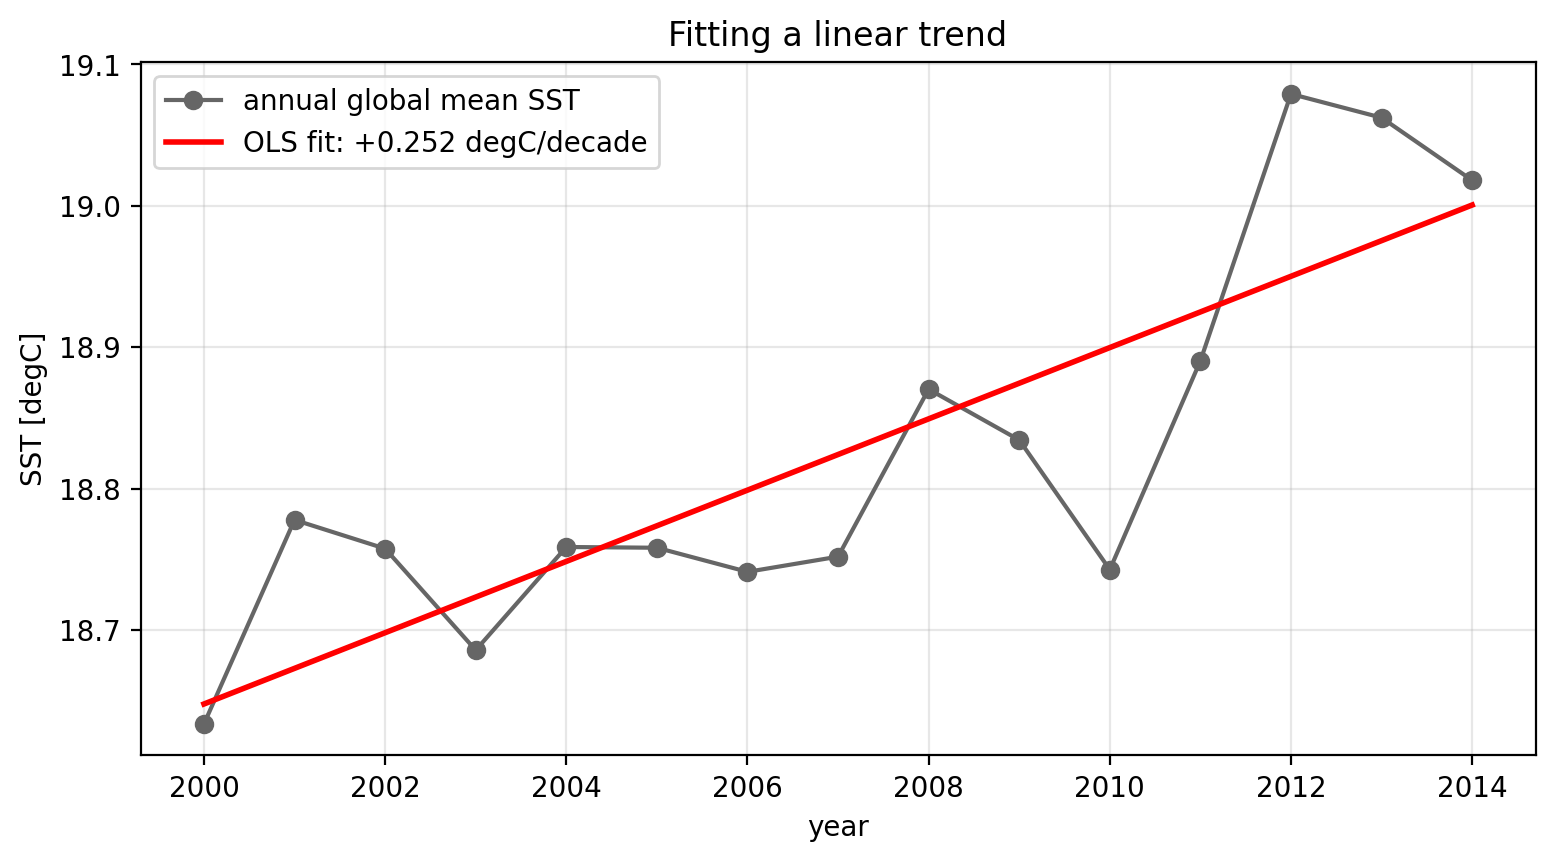

In [33]:
plt.figure(figsize=(9, 4.5))
plt.plot(years, annual_global, "o-", color="0.4", label="annual global mean SST")
plt.plot(years, fit.slope*years + fit.intercept, "r-", lw=2,
         label=f"OLS fit: {fit.slope*10:+.3f} degC/decade")
plt.ylabel("SST [degC]")
plt.xlabel("year")
plt.title("Fitting a linear trend")
plt.legend()
plt.grid(alpha=0.3)

The slope is **+0.252 degC/decade** and $r^2 = 0.697$, meaning the straight line
accounts for about 70% of the variance of the annual series. The remaining 30% is
the interannual wiggle around the line.

Do not read $r^2$ as evidence that the trend is real -- it only says how tightly
the points hug the line, and a short record with a lucky arrangement of noise can
produce a high $r^2$ with no underlying trend at all. That question needs
Section 9.2.

### Section 9.2: How uncertain is that slope?

The fitted slope is an estimate from a finite, noisy sample, so it comes with a
**standard error**. From that we get:

* a **confidence interval** -- roughly slope $\pm\, 1.96 \times$ standard error
  for 95% confidence,
* a **p-value** -- the probability of seeing a slope at least this large if the
  true slope were zero and the residuals were independent random noise.

The usual convention calls $p < 0.05$ "statistically significant". That phrase
means only "hard to explain by chance under my assumptions" -- it is not a
measure of how large, important, or physically meaningful the trend is.

In [34]:
ci = 1.96 * fit.stderr

print(f"slope          : {fit.slope*10:+.3f} degC/decade")
print(f"standard error : {fit.stderr*10:.3f} degC/decade")
print(f"95% CI         : {(fit.slope-ci)*10:+.3f} to {(fit.slope+ci)*10:+.3f} degC/decade")
print(f"p-value        : {fit.pvalue:.2e}")

slope          : +0.252 degC/decade
standard error : 0.046 degC/decade
95% CI         : +0.162 to +0.342 degC/decade
p-value        : 1.09e-04


A p-value of 0.00011 looks conclusive, and the confidence interval (+0.162 to
+0.342 degC/decade) comfortably excludes zero. If you stopped here you would
report a highly significant warming trend.

Do not stop here.

### Section 9.3: The autocorrelation trap

That p-value assumes the 15 annual values are **15 independent pieces of
information**. They are not. The ocean has a memory of months to years: a warm
year is followed by a warm year, because the heat is still there. Consecutive
values carry overlapping information, so the series contains fewer independent
samples than it has data points.

The standard first-order correction estimates the **lag-1 autocorrelation**
$r_1$ of the regression residuals and converts the sample size $n$ into an
**effective sample size**

$$ n_{\text{eff}} \;=\; n \, \frac{1 - r_1}{1 + r_1} $$

which is then used in place of $n$ when computing the significance of the slope.
(If $r_1 \le 0$ there is nothing to correct, so we cap $n_{\text{eff}}$ at $n$.)

In [35]:
def effective_n(residuals):
    """Effective sample size of an autocorrelated series (AR(1) approximation)."""
    r = np.asarray(residuals)
    r1 = float(np.corrcoef(r[:-1], r[1:])[0, 1])
    n = len(r)
    return min(n, n * (1 - r1) / (1 + r1)), r1


residuals = annual_global - (fit.slope * years + fit.intercept)
n_eff, r1 = effective_n(residuals)
n = len(annual_global)

# re-test the slope using n_eff instead of n
t_stat = fit.slope / fit.stderr
p_adjusted = 2 * stats.t.sf(abs(t_stat) * np.sqrt(n_eff / n), max(n_eff - 2, 1))

print(f"lag-1 autocorrelation of residuals : {r1:+.3f}")
print(f"sample size n                      : {n}")
print(f"effective sample size n_eff        : {n_eff:.1f}")
print(f"p-value, assuming independence     : {fit.pvalue:.2e}")
print(f"p-value, adjusted for autocorrelation : {p_adjusted:.4f}")

lag-1 autocorrelation of residuals : +0.320
sample size n                      : 15
effective sample size n_eff        : 7.7
p-value, assuming independence     : 1.09e-04
p-value, adjusted for autocorrelation : 0.0086


The 15 annual means are worth about **7.7 independent samples**, and the p-value
rises from 0.00011 to 0.0086 -- a factor of nearly 80. The trend survives, but
the evidence is much weaker than the naive number claimed.

Now watch what happens if you try to gain information by using the **monthly**
series instead of the annual one. Surely 180 points beat 15?

In [36]:
monthly_global = sst.weighted(coslat).mean(dim=["lat", "lon"])
mg = monthly_global.groupby("time.month")
monthly_anom = mg - mg.mean(dim="time")          # deseasonalised, as required

yr_frac = monthly_global["time"].dt.year + (monthly_global["time"].dt.month - 0.5) / 12
fit_m = stats.linregress(yr_frac, monthly_anom)

resid_m = monthly_anom - (fit_m.slope * yr_frac + fit_m.intercept)
n_eff_m, r1_m = effective_n(resid_m)

print(f"monthly slope   : {fit_m.slope*10:+.3f} degC/decade  (annual gave {fit.slope*10:+.3f})")
print(f"monthly p-value : {fit_m.pvalue:.2e}   <- looks overwhelming")
print(f"lag-1 autocorr  : {r1_m:.3f}")
print(f"n = {len(monthly_anom)}  ->  n_eff = {n_eff_m:.1f}")

monthly slope   : +0.251 degC/decade  (annual gave +0.252)
monthly p-value : 3.51e-34   <- looks overwhelming
lag-1 autocorr  : 0.955
n = 180  ->  n_eff = 4.2


```{admonition} The single most important number in this notebook
:class: important
The monthly fit reports $p = 3.5 \times 10^{-34}$. That number is meaningless.
The lag-1 autocorrelation of the monthly residuals is **0.955**, so the 180
monthly values are worth roughly **four** independent samples -- fewer than the
annual series, not more.

Twelve-times-denser sampling of a smoothly varying quantity adds almost no
information about its long-term trend; it only adds twelve times as many
correlated points, which the naive formula misreads as twelve times the evidence.

Both estimates agree on the thing that matters: over 2000-2014 this series
contains somewhere between four and eight independent samples, not 15 and
certainly not 180. Any trend conclusion has to live within that.
```

The AR(1) correction is itself a crude approximation -- it assumes a single
decorrelation timescale, and it is estimated from the same short record it is
correcting. Treat `n_eff` as an order-of-magnitude warning, not a precise
quantity. The honest summary is that the adjusted p-value is the one to quote,
and that it is uncertain too.

### Section 9.4: Mann-Kendall and Theil-Sen

OLS assumes the residuals are normally distributed and is sensitive to outliers
-- one bad value can swing the slope substantially. Hydrological series are
often skewed (streamflow, rainfall), contain outliers (floods), and sometimes
contain values below a detection limit. For those reasons the standard tools in
hydrology are **non-parametric**:

* The **Mann-Kendall test** asks only whether the series is **monotonic** -- does
  it tend to increase? It counts, over all pairs $i < j$, how many have
  $y_j > y_i$ against how many have $y_j < y_i$. It assumes nothing about the
  distribution of the data and nothing about the trend being a straight line.
  Kendall's $\tau$ runs from $-1$ (always decreasing) to $+1$ (always
  increasing).
* The **Theil-Sen slope** (Sen's slope) estimates the magnitude as the **median
  of the slopes of all pairs of points**. Because it is a median, it is
  essentially unaffected by a small number of extreme values -- it tolerates up
  to about 29% of the data being outliers before it breaks down.

Together they are the standard pairing: Mann-Kendall for *is there a trend*,
Theil-Sen for *how big is it*. `scipy.stats` has both.

In [37]:
tau, p_mk = stats.kendalltau(years, annual_global)
sen = stats.theilslopes(annual_global, years, 0.95)

print(f"Mann-Kendall tau : {tau:+.3f}   p = {p_mk:.4f}")
print(f"Theil-Sen slope  : {sen.slope*10:+.3f} degC/decade")
print(f"   95% CI        : {sen.low_slope*10:+.3f} to {sen.high_slope*10:+.3f} degC/decade")
print(f"OLS slope        : {fit.slope*10:+.3f} degC/decade  (for comparison)")

Mann-Kendall tau : +0.524   p = 0.0059
Theil-Sen slope  : +0.246 degC/decade
   95% CI        : +0.109 to +0.346 degC/decade
OLS slope        : +0.252 degC/decade  (for comparison)


The Theil-Sen slope (+0.246) and the OLS slope (+0.252) agree closely, which is
reassuring: it says the OLS fit is not being dragged around by one or two
extreme years. When the two **disagree** markedly, that is a signal to go and
look at the series for outliers or for a non-linear shape.

Mann-Kendall gives $p = 0.0059$, close to the autocorrelation-adjusted OLS value
of 0.0086 and far from the naive 0.00011. Note that plain Mann-Kendall is
*also* affected by autocorrelation -- for serious work you would use a
variance-corrected variant (Hamed-Rao or Yue-Pilon prewhitening, both available
in the `pymannkendall` package). We keep it simple here.

Let us bundle all of this into one reusable function.

In [38]:
def trend_report(series, time_years, label=""):
    """OLS + autocorrelation-adjusted p + Mann-Kendall + Theil-Sen, per decade."""
    t = np.asarray(time_years, dtype=float)
    y = np.asarray(series, dtype=float)

    ols = stats.linregress(t, y)
    n_eff, r1 = effective_n(y - (ols.slope * t + ols.intercept))
    p_adj = 2 * stats.t.sf(abs(ols.slope / ols.stderr) * np.sqrt(n_eff / len(t)),
                           max(n_eff - 2, 1))
    tau, p_mk = stats.kendalltau(t, y)
    sen = stats.theilslopes(y, t, 0.95)

    print(f"--- {label} (n = {len(t)}) ---")
    print(f"  OLS slope       : {ols.slope*10:+.3f} degC/decade "
          f"(95% CI {(ols.slope-1.96*ols.stderr)*10:+.3f} to {(ols.slope+1.96*ols.stderr)*10:+.3f})")
    print(f"  p, independent  : {ols.pvalue:.4f}")
    print(f"  p, autocorr-adj : {p_adj:.4f}   (n_eff = {n_eff:.1f}, r1 = {r1:+.2f})")
    print(f"  Mann-Kendall    : tau = {tau:+.3f}, p = {p_mk:.4f}")
    print(f"  Theil-Sen slope : {sen.slope*10:+.3f} degC/decade "
          f"(95% CI {sen.low_slope*10:+.3f} to {sen.high_slope*10:+.3f})")
    return dict(slope=ols.slope*10, p_adj=p_adj, sen=sen.slope*10, tau=tau, p_mk=p_mk)


_ = trend_report(annual_global, years, "global mean SST, 2000-2014")

--- global mean SST, 2000-2014 (n = 15) ---
  OLS slope       : +0.252 degC/decade (95% CI +0.162 to +0.342)
  p, independent  : 0.0001
  p, autocorr-adj : 0.0086   (n_eff = 7.7, r1 = +0.32)
  Mann-Kendall    : tau = +0.524, p = 0.0059
  Theil-Sen slope : +0.246 degC/decade (95% CI +0.109 to +0.346)


### Section 9.5: Trends everywhere -- the trend map

A global mean hides everything spatial. Fitting a separate trend at **every grid
point** turns the trend into a map, and xarray's `.polyfit()` does all 64,800
fits in one call.

There is one trap. `.polyfit(dim="time")` on a cftime axis converts the dates to
**nanoseconds**, so the slope comes back in degC per nanosecond -- a number like
$10^{-18}$ that is easy to misread as "no trend". The clean fix is to fit
against an explicit numeric year coordinate.

In [39]:
# the trap: fitting directly against the cftime axis
raw = annual_mean.polyfit(dim="time", deg=1)["polyfit_coefficients"].sel(degree=1)
print("slope against cftime axis :", float(raw.isel(lat=120, lon=310)), "degC per NANOSECOND")

# the fix: swap in a numeric 'year' coordinate, then fit against that
annual_by_year = annual_mean.assign_coords(year=("time", years.values)).swap_dims({"time": "year"})
trend_map = annual_by_year.polyfit(dim="year", deg=1)["polyfit_coefficients"].sel(degree=1) * 10

print("slope against year        :", round(float(trend_map.isel(lat=120, lon=310)), 3), "degC per decade")

slope against cftime axis : 1.3248109727646623e-18 degC per NANOSECOND


slope against year        : 0.418 degC per decade


area-weighted mean trend : +0.252 degC/decade
range across the ocean   : -1.34 to +2.95 degC/decade


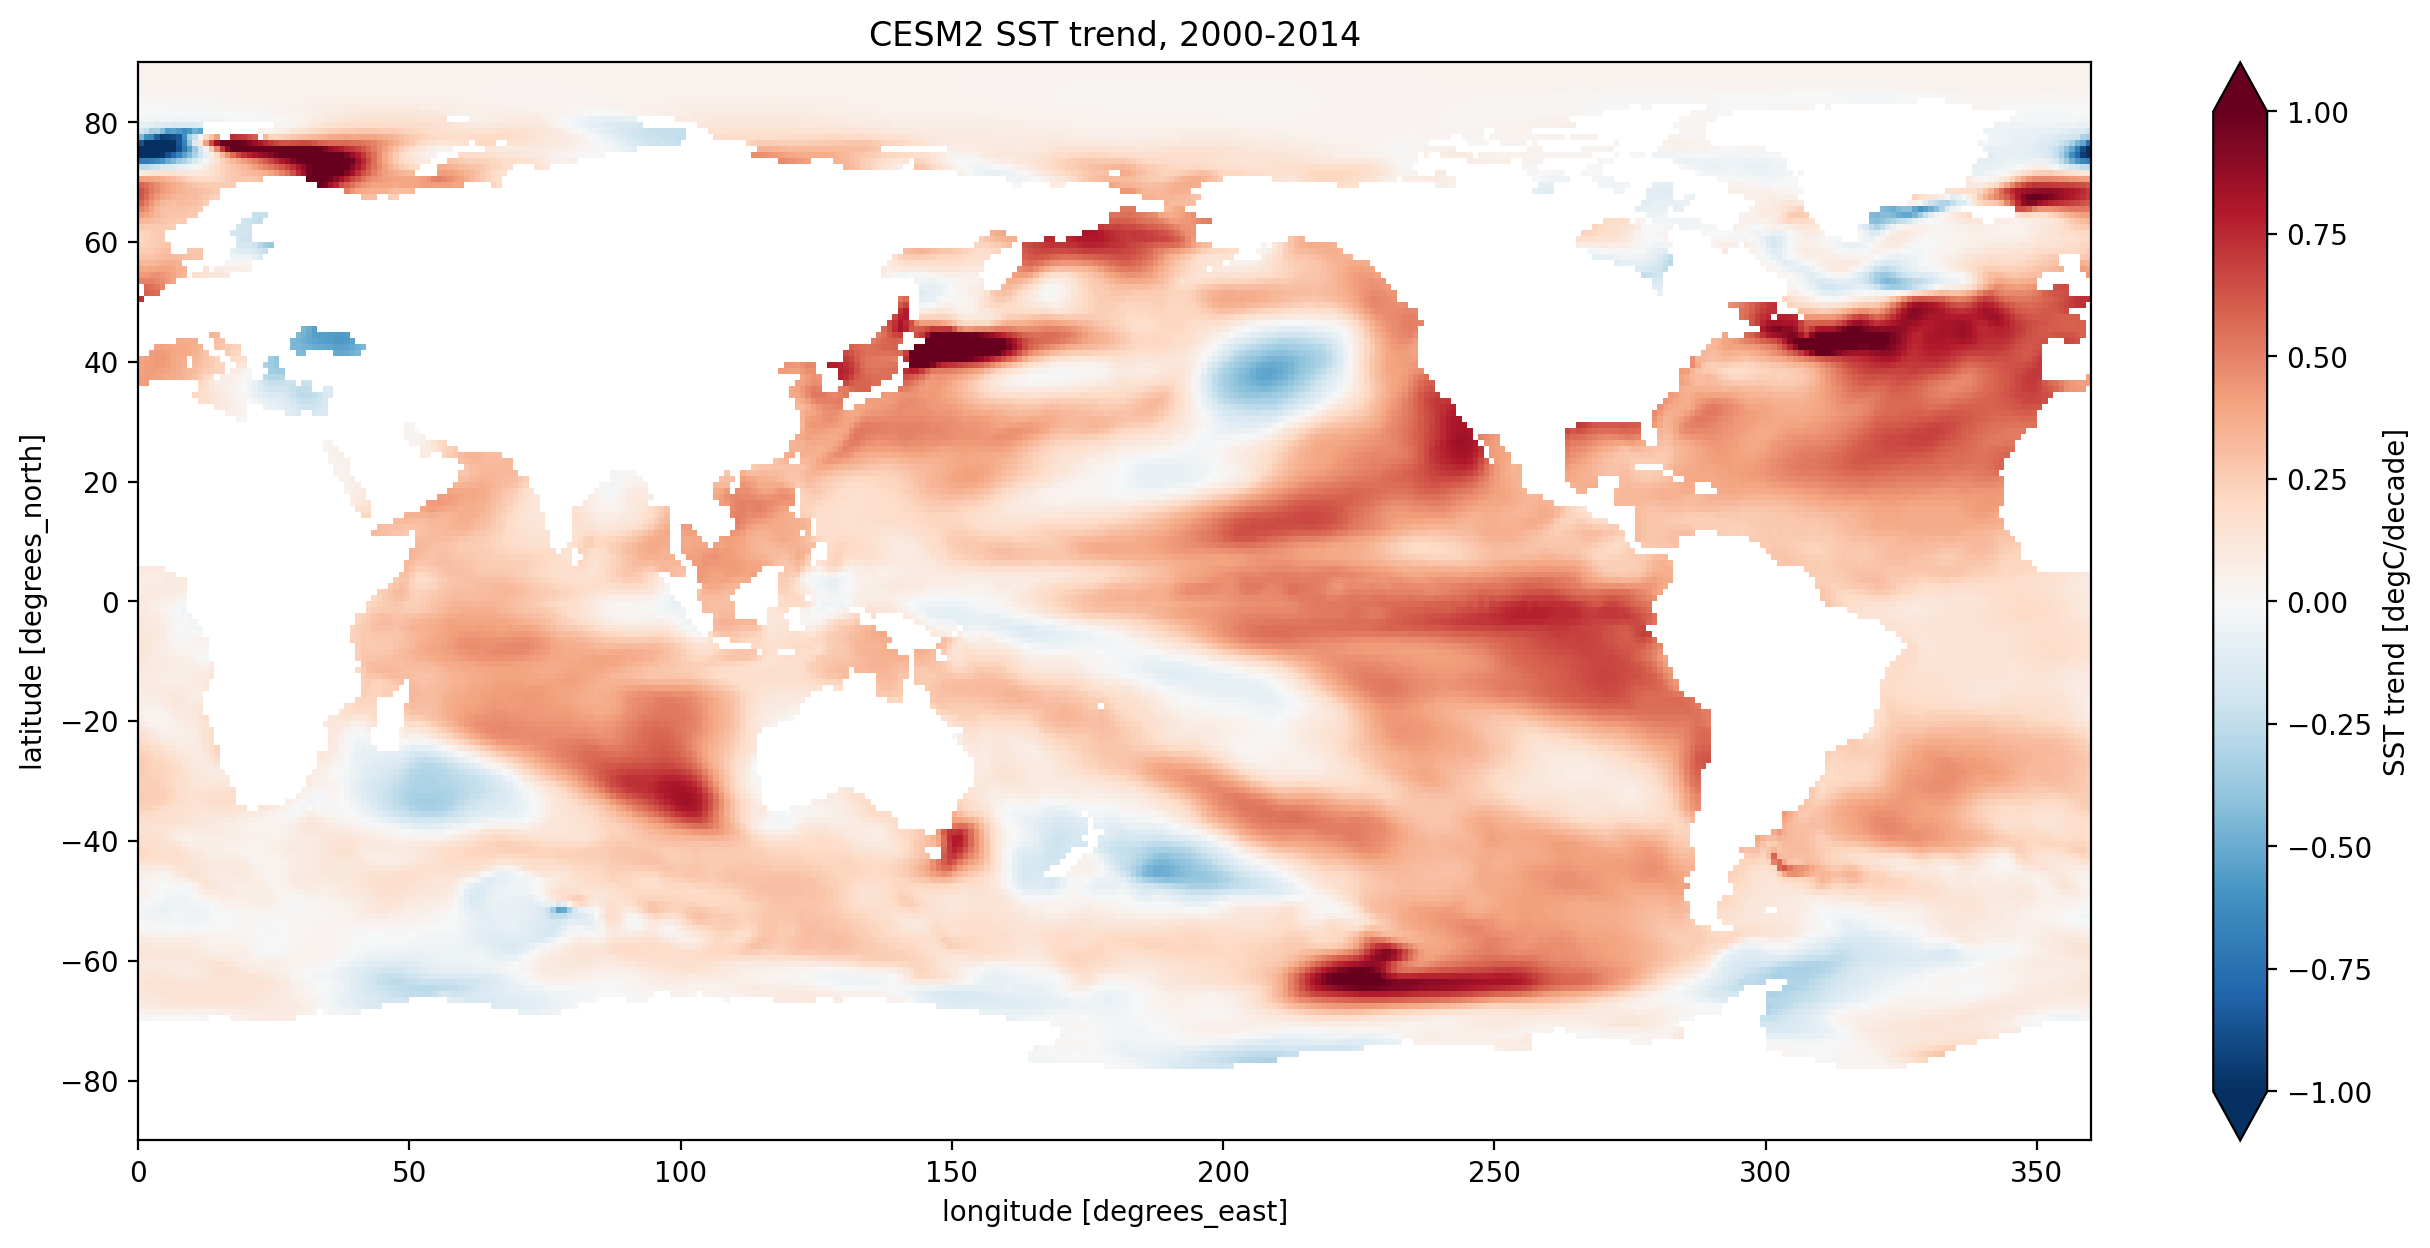

In [40]:
trend_map.plot(size=7, vmin=-1, vmax=1, cmap="RdBu_r",
               cbar_kwargs={"label": "SST trend [degC/decade]"})
plt.title("CESM2 SST trend, 2000-2014")

print(f"area-weighted mean trend : {float(trend_map.weighted(coslat).mean()):+.3f} degC/decade")
print(f"range across the ocean   : {float(trend_map.min()):+.2f} to {float(trend_map.max()):+.2f} degC/decade")

The area-weighted mean of this map is +0.252 degC/decade -- exactly the global
trend we fitted in Section 9.1, which is a useful check that the two routes
agree. But the *local* rates vary enormously around it: individual cells run
from about -1.3 to +2.9 degC/decade. Warming is not spatially uniform, and it is
the regional pattern, not the global mean, that matters for regional hydrology.

```{admonition} Two cautions about trend maps
:class: warning
**Multiple testing.** If you tested all 64,800 cells at the 5% level, you would
expect roughly 3,000 of them to come out "significant" by chance alone. Deciding
whether a *pattern* is significant is a separate problem called **field
significance**, usually handled by controlling the false discovery rate.

**Short records.** Over only 15 years the local trends are dominated by
internal variability -- ENSO alone can produce multi-degree swings in the
tropical Pacific. Much of the structure in this map is noise, not forced change.
```

### Section 9.6: How much should you believe a trend?

One last diagnostic, and the most sobering. Refit the *same* series over
different sub-periods and see how much the answer moves.

In [41]:
print("trend of the same series over different windows")
print(f"{'period':>12} {'n':>3} {'slope':>10} {'p':>8}")
for start, end in [(2000, 2014), (2000, 2007), (2007, 2014), (2002, 2012), (2001, 2013)]:
    sub = annual_global.sel(time=slice(str(start), str(end)))
    sub_years = sub["time"].dt.year
    f = stats.linregress(sub_years, sub)
    print(f"{start}-{end} {len(sub):>3} {f.slope*10:>+9.3f} {f.pvalue:>8.3f}")

trend of the same series over different windows
      period   n      slope        p
2000-2014  15    +0.252    0.000
2000-2007   8    +0.086    0.284
2007-2014   8    +0.441    0.014
2002-2012  11    +0.242    0.010
2001-2013  13    +0.240    0.003


The first half of the record warms at +0.086 degC/decade and is not significant
($p = 0.28$); the second half warms at +0.441 degC/decade. Split the same
15 years in two and you get answers differing by a factor of five. Move the
endpoints in by one or two years and the slope barely changes -- so this record
is not merely endpoint-sensitive, it genuinely contains a slow acceleration, or
a chunk of multi-year variability that a straight line cannot represent.

```{admonition} A checklist for reporting a trend
:class: tip
1. **Deseasonalise first** -- annual means or anomalies, never raw monthly data.
2. **Weight spatial averages by area** (Section 6).
3. **Quote an uncertainty**, not just a slope. A trend without a confidence
   interval is not a result.
4. **Correct for autocorrelation**, or use a method that accounts for it. The
   naive p-value is always too small.
5. **Check robustness** -- compare OLS with Theil-Sen, and refit over
   sub-periods.
6. **Respect the record length.** The WMO standard for a climate normal is
   **30 years**. Fifteen years of SST, as here, is genuinely too short to
   separate a forced trend from internal variability, however small the p-value
   looks. Say so, rather than letting the number speak for itself.
```

## Section 10: Putting it together -- a monsoon SST index

Everything above, applied end to end to one hydroclimatological question:
**how has the moisture source of the Indian summer monsoon behaved over
2000-2014?**

The recipe is: select a box, take an area-weighted mean, build the climatology,
subtract it for an anomaly, average to annual, and run the full trend report
from Section 9. Every step is a technique from this notebook, and the last one
is what keeps us honest.

In [42]:
# 1. select the northern Indian Ocean (Arabian Sea + Bay of Bengal)
box = sst.sel(lat=slice(5, 25), lon=slice(60, 95))

# 2. area-weighted spatial mean -> a time series
w = np.cos(np.deg2rad(box["lat"]))
nio = box.weighted(w).mean(dim=["lat", "lon"])

# 3. seasonal climatology
nio_clim = nio.groupby("time.month").mean(dim="time")

# 4. anomaly
nio_anom = nio.groupby("time.month") - nio_clim

# 5. annual means, then the full trend report from Section 9
nio_annual = nio.resample(time="YS").mean()
nio_years = nio_annual["time"].dt.year
yr = nio["time"].dt.year + (nio["time"].dt.month - 0.5) / 12   # numeric x for plotting

print(f"mean SST, N Indian Ocean : {float(nio.mean()):.2f} degC")
print(f"warmest month            : {int(nio_clim.idxmax()):d}  (1 = Jan)")
print()
_ = trend_report(nio_annual, nio_years, "northern Indian Ocean SST, 2000-2014")

mean SST, N Indian Ocean : 28.72 degC
warmest month            : 5  (1 = Jan)

--- northern Indian Ocean SST, 2000-2014 (n = 15) ---
  OLS slope       : +0.211 degC/decade (95% CI -0.052 to +0.475)
  p, independent  : 0.1394
  p, autocorr-adj : 0.1394   (n_eff = 15.0, r1 = -0.08)
  Mann-Kendall    : tau = +0.257, p = 0.2018
  Theil-Sen slope : +0.209 degC/decade (95% CI -0.074 to +0.560)


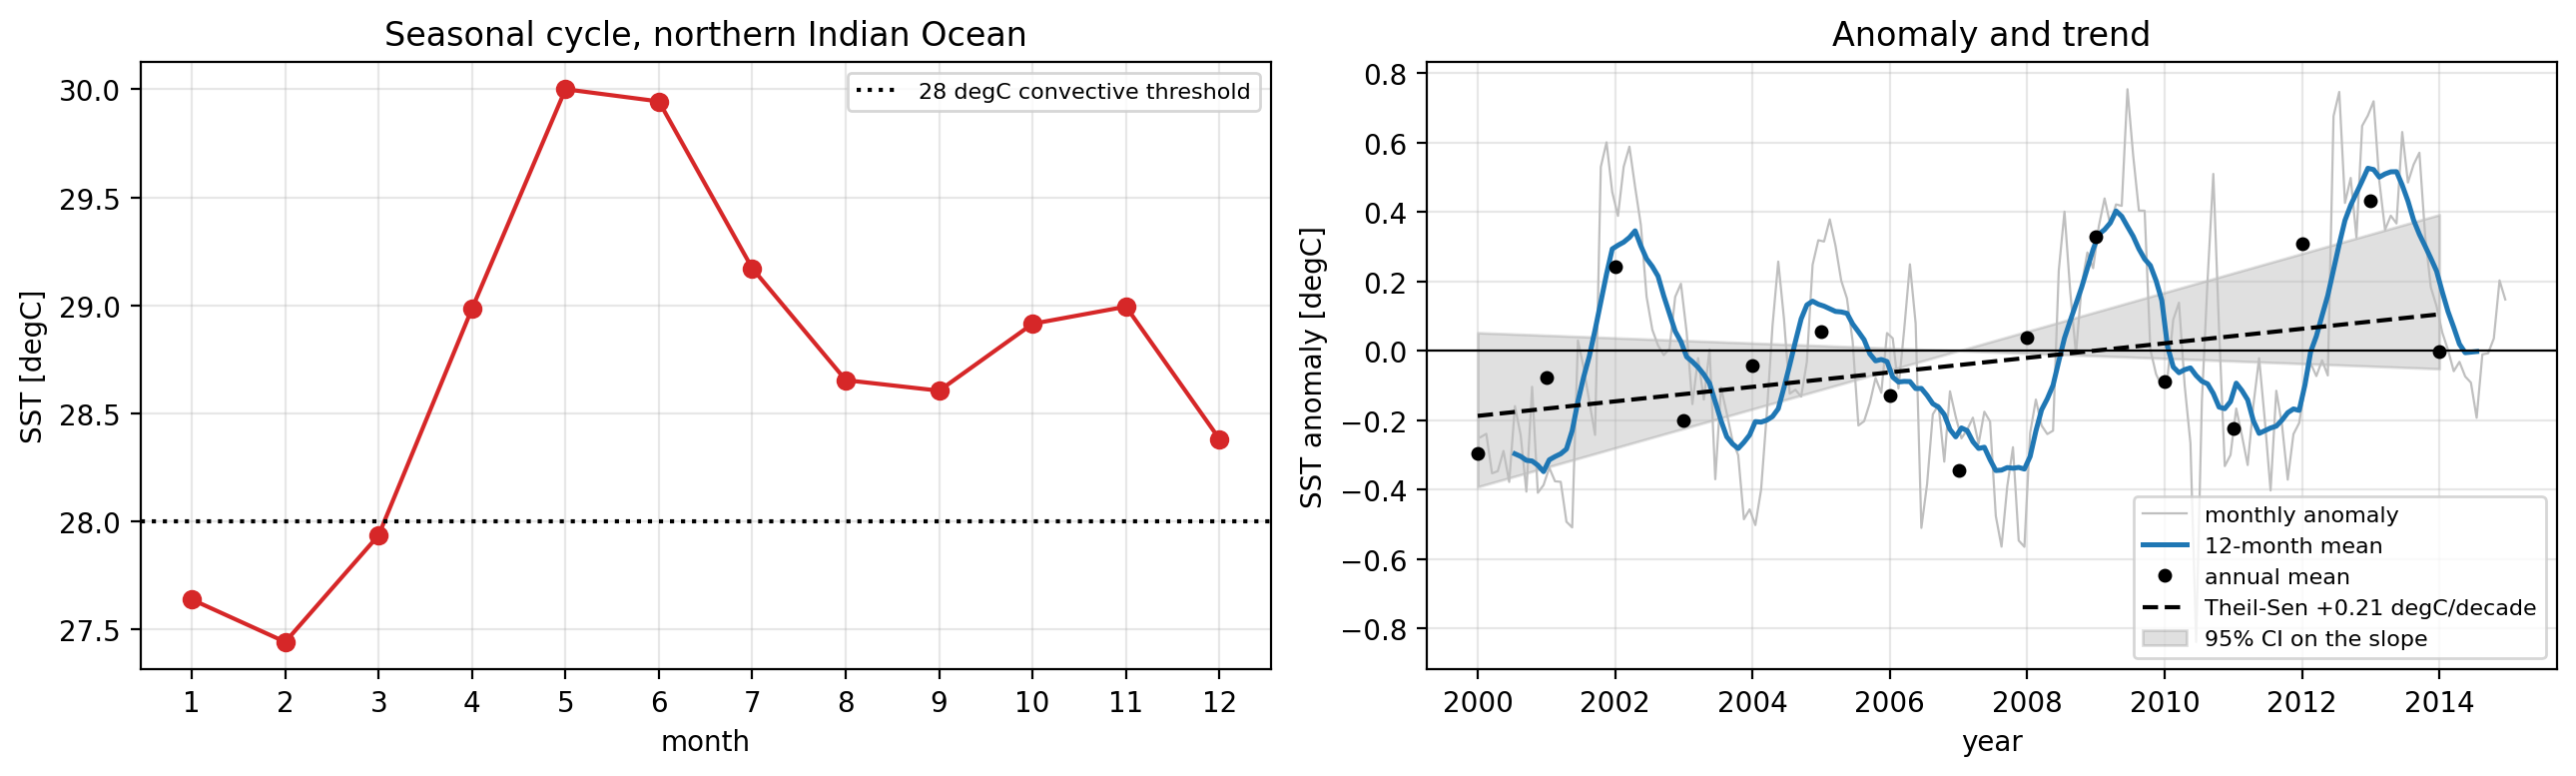

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(nio_clim["month"], nio_clim, "o-", color="tab:red")
ax[0].axhline(28, color="k", ls=":", label="28 degC convective threshold")
ax[0].set_xticks(range(1, 13))
ax[0].set_xlabel("month")
ax[0].set_ylabel("SST [degC]")
ax[0].set_title("Seasonal cycle, northern Indian Ocean")
ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3)

sen_nio = stats.theilslopes(nio_annual, nio_years, 0.95)
baseline = float(nio.mean())
annual_anom = nio_annual - baseline
centre = float(annual_anom.mean())

ax[1].plot(yr, nio_anom, lw=0.8, color="0.75", label="monthly anomaly")
ax[1].plot(yr, nio_anom.rolling(time=12, center=True).mean(),
           color="tab:blue", lw=1.8, label="12-month mean")
ax[1].plot(nio_years, annual_anom, "o", color="k", ms=4, label="annual mean")
ax[1].plot(nio_years, sen_nio.slope*nio_years + sen_nio.intercept - baseline, "k--",
           label=f"Theil-Sen {sen_nio.slope*10:+.2f} degC/decade")
ax[1].fill_between(nio_years,
                   sen_nio.low_slope*(nio_years - nio_years.mean()) + centre,
                   sen_nio.high_slope*(nio_years - nio_years.mean()) + centre,
                   color="k", alpha=0.12, label="95% CI on the slope")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_xlabel("year")
ax[1].set_ylabel("SST anomaly [degC]")
ax[1].set_title("Anomaly and trend")
ax[1].legend(fontsize=8)
ax[1].grid(alpha=0.3)
plt.tight_layout()

```{admonition} What the two panels say
:class: tip
**Left.** The seasonal cycle is **double-peaked**, which a single-peaked
mid-latitude intuition would never predict. SST rises steeply through the spring
to a maximum of 30.0 degC in **May**, falls through the monsoon to a minimum of
28.6 degC in **August-September**, then recovers to a second, smaller maximum of
29.0 degC in **November**.

That mid-year trough is the monsoon cooling its own moisture source. Once the
southwesterly winds set in, they drive strong evaporative heat loss, deepen the
mixed layer by mixing, shade the surface with cloud, and force coastal upwelling
off Somalia and Oman. The ocean here is not a passive boundary condition: it
responds to the circulation it drives, which is a negative feedback on the
monsoon itself.

Note also that the basin stays above the 28 degC convective threshold from
**April through December** -- only February and March fall below -- which is why
it can sustain deep convection for most of the year.

**Right.** The basin warms at about **+0.21 degC/decade** -- and that trend is
**not statistically significant**. Read the numbers the report printed: OLS
gives $p = 0.14$, Mann-Kendall gives $p = 0.20$, and the Theil-Sen 95%
confidence interval runs from **-0.07 to +0.56** degC/decade. It contains zero,
which is why the shaded band on the plot is wide enough to accommodate a flat
line.

This is the whole point of Section 9. Fifteen years of a single model
realisation cannot resolve a trend against interannual variability this large.
The defensible sentence is *"this run warms the basin at +0.21 degC/decade over
2000-2014, a trend indistinguishable from zero at 95% confidence"* -- not "the
northern Indian Ocean is warming".

Compare with the global mean in Section 9, which had a very similar slope
(+0.25 degC/decade) but *was* significant. Same record length, same method: the
difference is that averaging over the whole globe cancels far more internal
variability than averaging over one basin. **Smaller region, noisier series,
weaker conclusion.** Exercise 9 repeats this on 50 years of ERSST observations,
where the record is long enough for the question to be answerable.
```

## Exercises

Work these in a fresh cell. Hints are given; solutions are not.

**1. Selection.** Extract the SST time series at a point in the Bay of Bengal
(roughly 15N, 88E) and plot it against an Arabian Sea point (roughly 15N, 65E)
on the same axes. Which basin is warmer, and which has the larger seasonal
range? *Hint: `method="nearest"` for both.*

**2. Aggregation.** Compute the **standard deviation of SST over time** at every
grid point (`sst.std(dim="time")`) and map it. Where is interannual variability
largest, and why is the tropical Pacific so prominent? *Hint: think about ENSO.*

**3. Climatology.** Instead of monthly, compute a **seasonal** climatology with
`sst.groupby("time.season").mean(dim="time")`, then plot the four seasons as a
2x2 panel using `.plot(col="season", col_wrap=2)`. *Hint: xarray's faceting does
the whole grid in one call.*

**4. Weighting.** Recompute the global mean SST **trend** two ways -- unweighted
and cos-latitude weighted -- and report both with `trend_report`. How large is
the error introduced by forgetting the weights, compared with the confidence
interval on the slope?

**5. Resampling.** Build a **JJA (June-July-August) mean** SST series for the
northern Indian Ocean box from Section 10, and compare its trend with the
all-months trend. Is the monsoon season warming faster or slower -- and is
either trend significant? *Hint:
`nio.sel(time=nio["time"].dt.season == "JJA").groupby("time.year").mean()`,
then `trend_report`.*

**6. Masking.** For each month in the record, compute the **fraction of global
ocean area with SST >= 28 degC** and plot it as a time series. Does the warm
pool grow over 2000-2014? *Hint: weight the sum of `areacello` where
`sst >= 28` by the total ocean area, month by month, exactly as in Section 8.*
Then run `trend_report` on the annual means of that fraction -- is the growth
significant?

**7. Trend maps.** From the trend map in Section 9.5, find the ocean region
warming fastest and the largest region that is *cooling*. Pick a 5x5 degree box
in each, extract its annual series, and run `trend_report`. How many survive the
autocorrelation correction? *This is the multiple-testing caution of
Section 9.5 made concrete.*

**8. Robustness.** Take the global annual series, add 3 degC to a single year,
and refit. How far does the **OLS** slope move, and how far does the
**Theil-Sen** slope move? *This is what "robust to outliers" buys you, and why
hydrologists reach for it when a record contains a flood year.*

## Summary

You now have the working vocabulary of gridded climate data analysis:

| task | tool |
|---|---|
| open a netCDF file | `xr.open_dataset()` |
| select by label / position | `.sel()` / `.isel()`, `method="nearest"`, `slice()` |
| element-wise maths | ordinary operators (vectorized) |
| reduce a dimension | `.mean(dim=...)`, `.min()`, `.std()`, `.count()` |
| seasonal cycle | `.groupby("time.month").mean()` |
| anomaly | `gb - gb.mean(dim="time")` |
| honest spatial mean | `.weighted(areacello).mean(...)`, or `cos(lat)` |
| change frequency | `.resample(time="YS")` |
| smooth | `.rolling(time=n, center=True).mean()` |
| block-average | `.coarsen(...)` |
| mask | `.where(cond)`, combined with `&`, `|`, `~` |
| linear trend | `scipy.stats.linregress` |
| robust trend | `stats.kendalltau` + `stats.theilslopes` |
| trend at every grid point | `.polyfit(dim=..., deg=1)` |

Three ideas are worth more than the syntax:

1. **Labels are not decoration.** They are what makes `mean(dim="time")`
   possible, what aligns two datasets correctly, and what keeps you from
   averaging the wrong axis.
2. **Area weighting is not optional.** Any spatial average on a lat-lon grid
   needs it, and the error is large enough to change conclusions.
3. **The climatology-plus-anomaly decomposition is the central move** in climate
   analysis. Almost every index you will meet -- ENSO's Nino 3.4, the Dipole
   Mode Index, a standardised precipitation index -- is an area-weighted mean of
   an anomaly field.
4. **A trend without an uncertainty is not a result.** Climate series are
   autocorrelated, so the textbook p-value is always too optimistic, and a
   15-year record cannot settle a question that needs 30. The northern Indian
   Ocean trend in Section 10 is a worked example of a number that looks
   convincing and is not.

**Where to go next:** Exercise 9 applies exactly these operations to 50 years of
observed SST to build the Indian Ocean Dipole index; Lecture 11 explains the
ocean heat transport that shapes the mean SST map you plotted in Section 4.

## Credits and further reading

This notebook is adapted for **CE524 Applied Hydroclimatology, IIT Mandi** by
Vivek Gupta, from:

* **ClimateMatch Academy, Computational Tools for Climate Science**, Week 1
  Day 1 *Climate System Overview*, Tutorials 4-9 -- content creators Sloane
  Garelick and Julia Kent. <https://comptools.climatematch.io/> (CC BY 4.0)
* **Project Pythia Foundations** -- Rose, B. E. J., Kent, J., Tyle, K.,
  Clyne, J., Banihirwe, A., Camron, D., May, R., Grover, M., Ford, R. R.,
  Paul, K., Morley, J., Eroglu, O., Kailyn, L., & Zacharias, A. (2023).
  *Pythia Foundations* (v2023.05.01). <https://zenodo.org/record/8065851>

Adaptations made here: the tutorials were merged into a single narrative and
reordered; the videos, feedback widgets and Colab form cells were removed;
deprecated calls were updated for current xarray (`"AS"` to `"YS"`); the
area-weighting discussion was expanded and given a cosine-latitude alternative;
and the whole of Section 9 (trend analysis: least squares, effective sample
size, Mann-Kendall, Theil-Sen, trend mapping), the monsoon index in Section 10,
the exercises, and the hydroclimatology framing throughout are new.

**Data:** CESM2 (CMIP6) monthly `tos`, via the
[Project Pythia dataset registry](https://github.com/ProjectPythia/pythia-datasets).

**Further reading**

* [Xarray user guide](https://docs.xarray.dev/en/stable/user-guide/index.html) --
  the reference for everything in this notebook.
* [Xarray tutorial](https://tutorial.xarray.dev/) -- longer worked examples.
* [Pythia Foundations](https://foundations.projectpythia.org/) -- the wider
  Python-for-geoscience stack: dask, cartopy, CF conventions.
* Helsel, D. R., Hirsch, R. M., Ryberg, K. R., Archfield, S. A., & Gilroy, E. J.
  (2020). *Statistical Methods in Water Resources*. USGS Techniques and Methods
  4-A3. <https://doi.org/10.3133/tm4a3> -- the standard reference for
  Mann-Kendall and Theil-Sen in hydrology, free to download.
* [`pymannkendall`](https://pypi.org/project/pymannkendall/) -- implements the
  autocorrelation-corrected Mann-Kendall variants (Hamed-Rao, Yue-Pilon)
  mentioned in Section 9.4.